# FX Trading Bot (EUR/USD)

<img src= "images/Candlestick_chart.svg" alt="EUR/USD chart" width="800">

* A EUR/USD trading bot using various quant and technical strategies layered together for the Asia/LDN/NY sessions

***
***

## 0) Notebook Dependencies

In [1]:
# Core Dependencies
import os
import warnings
warnings.filterwarnings("ignore")

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")

# ------------------------------------------------------------
# Robust optional/import handling
# ------------------------------------------------------------

def optional_import(module_name, alias=None):
    """
    Try to import optional research/deployment libraries without crashing the notebook.
    Returns the module or None.
    """
    try:
        module = __import__(module_name)
        return module
    except Exception as exc:
        print(f"Optional dependency skipped: {module_name} ({exc})")
        return None

# Financial data and technical analysis dependencies
try:
    import yfinance as yf
except Exception as exc:
    raise ImportError(
        "yfinance is required for the data download cells. Install it with: pip install yfinance"
    ) from exc

try:
    import ta
    from ta import add_all_ta_features
except Exception as exc:
    raise ImportError(
        "ta is required for technical indicators. Install it with: pip install ta"
    ) from exc

# Machine learning dependencies
from sklearn.base import clone
from sklearn.model_selection import TimeSeriesSplit
from sklearn.cluster import KMeans, AgglomerativeClustering, FeatureAgglomeration
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
)

try:
    from xgboost import XGBClassifier
except Exception as exc:
    raise ImportError(
        "xgboost is required for the model cells. Install it with: pip install xgboost"
    ) from exc

try:
    import optuna
except Exception as exc:
    raise ImportError(
        "optuna is required for the hyperparameter tuning cells. Install it with: pip install optuna"
    ) from exc

# Optional research/deployment dependencies.
# These are not needed for the core notebook to run.
try:
    from hdbscan import HDBSCAN
except Exception as exc:
    HDBSCAN = None
    print(f"Optional dependency skipped: hdbscan ({exc})")

try:
    from pytorch_tcn import TCN
except Exception as exc:
    TCN = None
    print(f"Optional dependency skipped: pytorch_tcn ({exc})")

try:
    import hmmlearn as hmm
except Exception as exc:
    hmm = None
    print(f"Optional dependency skipped: hmmlearn ({exc})")

try:
    import backtrader as bt
except Exception as exc:
    bt = None
    print(f"Optional dependency skipped: backtrader ({exc})")

try:
    import docker
except Exception as exc:
    docker = None
    print(f"Optional dependency skipped: docker ({exc})")

try:
    import mlflow
    import mlflow.sklearn
    import mlflow.xgboost
    from mlflow.models import infer_signature
except Exception as exc:
    mlflow = None
    infer_signature = None
    print(f"Optional dependency skipped: mlflow ({exc})")

***
***

## 1) Business Understanding

### 1.1 Problem Definition.


#### Business Objective

Design and validate a **systematic, ML‑assisted EUR/USD trading framework** that:

- Starts with a **small trading account (~$200)**.
- Focuses initially on **intraday / day‑trading horizons**.
- Prioritizes **capital protection, low volatility, and consistent returns** over “max profit”.
- Is **fully systematic** (no discretionary/manual chart reading).
- Can **scale over time** into:
  - multi‑session trading (Asia / London / NY),
  - swing trading,
  - positional (macro‑driven) trading,
  - and eventually a **live automated trading bot**.

The primary business problem is:  
> “Can we build an objectively testable, risk‑controlled EUR/USD strategy driven by quant & ML methods that is viable for a small account and realistically scalable?”



#### What We Are NOT Doing

- No discretionary/manual “gut feeling” trades.
- No overfitted backtests with unrealistic assumptions.
- No expectation of getting rich from a $200 account.
- No trying to predict exact future prices tick‑by‑tick.
- No using ML as a black box without understanding the trading context.



#### End Products

This project aims to produce:

- A clean, feature‑engineered **EUR/USD intraday dataset**.
- A set of **ML models** (starting from simple baselines → more advanced models).
- A **strategy logic layer** that converts model outputs into trade decisions (entries/exits).
- A **risk management module** that keeps drawdowns acceptable for a small account.
- A **deployment plan** for an automated trading bot (running via broker API).

***

### 1.2 Business Constraints



#### Capital Constraints

- Starting capital: approximately **$200**.
- Position sizes must be **micro‑lots (0.01)** or equivalent.
- Maximum risk per trade: **0.25–0.5%** of account.
- Strategy must survive inevitable losing streaks without blowing up the account.

#### Market Constraints

- Instrument: **EUR/USD**, a major FX pair with high liquidity and tight spreads.
- Market is open 24h (Mon–Fri) but **behaviour changes by session**:
  - Asia: lower volatility, more ranges.
  - London: higher volatility, breakouts and trends.
  - NY: continuation or reversals, plus US data releases.
- Need to **avoid trading around major news** (NFP, CPI, FOMC, ECB) to protect a small account.

#### Operational Constraints

- Use **Python** with open‑source tools (pandas, numpy, scikit‑learn, etc.).
- Historical data source for research: **`yfinance`**, later replaceable by broker API data.
- No assumptions of tick‑level precision or institutional infrastructure.
- Models must be simple enough to monitor, debug, and retrain as needed.
***

### 1.3 Objectives & Success Criteria



#### Primary Success Criteria (Trading Performance)

The system is considered successful if, on realistic backtests and forward tests:

- **Expectancy per trade > 0** (profitable on average).
- **Maximum drawdown** is kept below a target threshold (e.g. 15–25%).
- **Profit factor > 1.2–1.5** (total gains / total losses).
- **Risk‑adjusted returns**:
  - Sharpe or Sortino ratio above a chosen minimum (e.g. > 1.0–1.5).
- Performance is **reasonably stable across time**:
  - not coming from one lucky month or regime only.
  - holds out‑of‑sample and on unseen periods.

#### Secondary Success Criteria (ML Metrics)

Model‑level metrics are useful but not the final objective:

- Accuracy, precision, recall for trade success classification.
- Calibration of predicted probabilities.
- Stability of model performance across rolling windows.
- AUC/F1 used **only as a guide**, not as the main optimization target.

Trading metrics > ML metrics.
Models are judged by strategy performance, not just statistical scores.

***

### 1.4 Domain Understanding (Trading Concepts)


#### Forex Basics

- We trade **currency pairs**; here, **EUR/USD** (Euro vs US Dollar).
- Price expresses how many USD one Euro is worth.
- Core mechanics:
  - **Pips**: smallest price unit (0.0001 for EUR/USD).
  - **Lots**: position size (1 lot = 100k units; we use micro‑lots like 0.01).
  - **Spread**: difference between bid and ask; cost of entering a trade.
  - **Leverage**: allows controlling a larger notional position with small capital (dangerous if misused).
  - **Margin**: amount of capital locked as collateral when a trade is open.

#### Liquidity

- EUR/USD is the **most liquid pair** in FX:
  - tightest spreads,
  - lowest slippage,
  - smoother price action compared to exotics.
- High liquidity is ideal for:
  - day‑trading,
  - ML modeling (less random gaps/spikes),
  - small‑account trading.

#### Sessions & Time‑of‑Day Effects

- **Asia session**: generally low volatility, more sideways movement.
- **London session**: high liquidity and volatility, common breakouts and intraday trends.
- **NY session**: strong moves around US data; mix of continuation and reversals.
- **Late NY**: often low activity and choppy noise.

Session behaviour will be **confirmed empirically** in the Data Understanding phase and later used as features (e.g. `session`, `hour_of_day`).

#### Macro Fundamentals (Minimal Usage for Now)

- Macro drivers: interest rates, inflation data, employment data, central bank decisions.
- For this project’s first phase:
- Fundamentals are used mainly to identify **“no‑trade” windows** around high‑impact news.
- Objective is to **avoid** extremely unpredictable conditions rather than model macro directly at first.


***

### 1.5 Analytical Questions


#### Market Behaviour Questions

1. How does **volatility** (range, ATR, return magnitude) vary by hour of day and session (Asia/London/NY)?
2. Is there statistical evidence of:
   - **mean reversion** in certain hours/sessions?
   - **breakouts** after periods of volatility compression?
   - **trend persistence** intraday?
3. What are the typical intraday **range sizes** and holding periods that are feasible with small capital?

#### Modeling Questions

4. Which features (returns, volatility, candle patterns, time‑of‑day, range distance) show useful relationships with future price movement?
5. Does including **session/time features** improve predictability?
6. Can we define **trade events** where the model’s prediction is meaningful (i.e., non‑random payoff distributions)?

#### Risk & Money Management Questions

7. What stop‑loss and take‑profit distances make sense for EUR/USD on 5‑minute data given spreads and small account size?
8. How sensitive is strategy performance to:
   - risk per trade,
   - max number of trades per day,
   - session filters?

#### Strategy Questions

9. In which contexts does **mean reversion** perform better than **breakout** or **trend‑following**, and vice versa?
10. Can we identify **market regimes** (range, trend, high‑vol news, dead) using unsupervised methods (e.g. clustering, HMMs)?
11. How well do model‑based entry filters (probability thresholds) improve raw rule‑based strategies?

#### Bot & Deployment Questions

12. What is the simplest reliable architecture to:
    - fetch data in real time,
    - generate features,
    - apply models and risk logic,
    - execute trades via broker API,
    - and log everything for monitoring and retraining?


***

***


## 2) Data Understanding

### 2.1 Data Sources

#### 2.1.1 Price Data (Primary)

- For the initial research/prototyping phase:

  - Use `yfinance` to obtain:
    - 5-minute EUR/USD data for the last ~60 days (intraday structure, sessions, initial modeling).
    - 1-hour and/or daily data for 1–5 years (long-term volatility and regime analysis).

- For later production-grade modeling and backtesting:

  - Plan to switch to broker or dedicated FX historical data for:
    - 5-minute (or 1-minute) EUR/USD over 2–5+ years.

- Fields:
  - `Datetime` (index, UTC or local timezone depending on feed)
  - `Open`, `High`, `Low`, `Close`
  - `Volume` (for FX via Yahoo this is typically 0 or not meaningful → will be ignored)

This dataset will be used for:

- Session and volatility analysis (Data Understanding).
- Feature engineering (Data Preparation).
- ML model training and backtesting (Modeling & Evaluation).

> **Note:** In later phases, the Yahoo data can be replaced or augmented with broker‑specific data (e.g., OANDA/MT5) to align historical tests more closely with live trading conditions.

#### 2.1.2 1‑Minute Data (Optional / Short Window)

- Yahoo Finance provides **1‑minute data** only for relatively short lookback windows (e.g., last 7 days).
- Usage in this project:
  - **NOT** for long‑term backtesting or primary ML training (history too short, too noisy).
  - Used instead for:
    - microstructure exploration,
    - checking behaviour around entries and exits,
    - testing live data pipelines and bot execution.

#### 2.1.3 Economic Calendar / News Data (Planned)

- Purpose: filter out **high‑impact news windows** where price behaviour is extremely unstable.
- Content needed:
  - Event timestamp (UTC)
  - Event name and currency (e.g., US NFP, US CPI, ECB rate decision)
  - Impact rating (low/medium/high)
- Usage:
  - Create features like `is_high_impact_news_now`, `is_high_impact_news_next_30m`.
  - Hard “no‑trade” rule around major events for small account safety.

In early prototyping, this can be mocked or added later once the core price‑based pipeline is stable.

***


### 2.2 Loading the datasets and inspecting for missing values

#### 2.2.1) 5 min interval(60 days)

In [2]:
# Loading the historical price from yfinance for the EURUSD for the last 60 days at 5 min intervals

def flatten_yfinance_columns(df):
    """
    yfinance sometimes returns MultiIndex columns like ('Close', 'EURUSD=X').
    The rest of this notebook expects single-level OHLCV column names.
    """
    df = df.copy()
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [col[0] for col in df.columns]
    else:
        df.columns = [str(col) for col in df.columns]

    # Make sure the columns used by the TA and modelling sections exist.
    for required_col in ["Open", "High", "Low", "Close"]:
        if required_col not in df.columns:
            raise KeyError(f"Downloaded data is missing required column: {required_col}")

    if "Volume" not in df.columns:
        df["Volume"] = 0.0

    return df


def download_fx_data(ticker="EURUSD=X", interval="5m", period="60d"):
    data = yf.download(
        tickers=ticker,
        interval=interval,
        period=period,
        auto_adjust=False,
        progress=False,
    )
    data = pd.DataFrame(data)
    if data.empty:
        raise ValueError(
            f"No data returned for ticker={ticker}, interval={interval}, period={period}. "
            "Check your internet connection or yfinance limits."
        )

    data.index = pd.to_datetime(data.index)
    data = flatten_yfinance_columns(data)
    data = data.sort_index()
    return data


five_min = download_fx_data(ticker="EURUSD=X", interval="5m", period="60d")
five_min.tail()

,Adj Close,Close,High,Low,Open,Volume
Datetime,,,,,,
2026-07-02 10:55:00+00:00,1.141292,1.141292,1.141422,1.141162,1.141422,0
2026-07-02 11:00:00+00:00,1.141292,1.141292,1.141422,1.141162,1.141422,0
2026-07-02 11:05:00+00:00,1.141162,1.141162,1.141292,1.141032,1.141292,0
2026-07-02 11:10:00+00:00,1.141422,1.141422,1.141422,1.141292,1.141292,0
2026-07-02 11:15:00+00:00,1.141422,1.141422,1.141422,1.141422,1.141422,0


In [3]:
five_min.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 16819 entries, 2026-04-09 23:00:00+00:00 to 2026-07-02 11:15:00+00:00
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  16819 non-null  float64
 1   Close      16819 non-null  float64
 2   High       16819 non-null  float64
 3   Low        16819 non-null  float64
 4   Open       16819 non-null  float64
 5   Volume     16819 non-null  int64  
dtypes: float64(5), int64(1)
memory usage: 919.8 KB


#### 2.2.2) 1 min interval(7 days)

In [4]:
# Loading the historical data for 1 min intervals for the last 7 days

one_min = download_fx_data(ticker="EURUSD=X", interval="1m", period="7d")
one_min.tail()

,Adj Close,Close,High,Low,Open,Volume
Datetime,,,,,,
2026-07-02 11:13:00+00:00,1.141422,1.141422,1.141422,1.141422,1.141422,0
2026-07-02 11:14:00+00:00,1.141422,1.141422,1.141422,1.141422,1.141422,0
2026-07-02 11:15:00+00:00,1.141422,1.141422,1.141422,1.141422,1.141422,0
2026-07-02 11:16:00+00:00,1.141422,1.141422,1.141422,1.141422,1.141422,0
2026-07-02 11:17:00+00:00,1.141422,1.141422,1.141422,1.141422,1.141422,0


In [5]:
one_min.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9280 entries, 2026-06-23 23:00:00+00:00 to 2026-07-02 11:17:00+00:00
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  9280 non-null   float64
 1   Close      9280 non-null   float64
 2   High       9280 non-null   float64
 3   Low        9280 non-null   float64
 4   Open       9280 non-null   float64
 5   Volume     9280 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 507.5 KB


#### 2.2.3) 1 day interval(2 years)

In [6]:
# Loading the 1 day trading data for the last 2 years

day_data = download_fx_data(ticker="EURUSD=X", interval="1d", period="2y")
day_data.tail()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2026-06-26,1.136170,1.136170,1.143393,1.135486,1.136389,0
2026-06-29,1.138563,1.138563,1.142596,1.138174,1.138446,0
2026-06-30,1.142204,1.142204,1.143445,1.138330,1.141891,0
2026-07-01,1.141331,1.141331,1.141683,1.136209,1.141253,0
2026-07-02,1.141422,1.141422,1.142335,1.137786,1.138174,0


In [7]:
day_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 518 entries, 2024-07-02 to 2026-07-02
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  518 non-null    float64
 1   Close      518 non-null    float64
 2   High       518 non-null    float64
 3   Low        518 non-null    float64
 4   Open       518 non-null    float64
 5   Volume     518 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 28.3 KB


#### 2.2.4) Economic news

In [8]:
# Loading the economic news data set

events_df = pd.read_csv("data/economic calendar dataset/Calender_data.csv", index_col='id')

events_df.head()

,date,time,zone,currency,importance,event,actual,forecast,previous
id,,,,,,,,,
9,01/01/2020,All Day,united states,NaN,NaN,United States - New Year's Day,NaN,NaN,NaN
9,01/01/2020,All Day,united kingdom,NaN,NaN,United Kingdom - New Year's Day,NaN,NaN,NaN
9,01/01/2020,All Day,germany,NaN,NaN,Germany - New Year's Day,NaN,NaN,NaN
9,01/01/2020,All Day,switzerland,NaN,NaN,Switzerland - New Year's Day,NaN,NaN,NaN
9,01/01/2020,All Day,italy,NaN,NaN,Italy - New Year's Day,NaN,NaN,NaN


In [9]:
events_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 663497 entries, 9 to 693
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   date        663497 non-null  object
 1   time        656887 non-null  object
 2   zone        663497 non-null  object
 3   currency    115290 non-null  object
 4   importance  115290 non-null  object
 5   event       663497 non-null  object
 6   actual      106757 non-null  object
 7   forecast    40317 non-null   object
 8   previous    106818 non-null  object
dtypes: object(9)
memory usage: 50.6+ MB


* Form loading and using the `.info()` method, all the price data seems to have no missing values with all of the columns except _Volume_ to be float datatypes. The Economic event calendar seems to have various missing values, however it may not be the case when we select out events that are to do with `USD` and `EUR` only.

In [10]:
# Selecting relevant events for the target currencies

relevant_events = events_df[events_df['currency'].isin(['EUR', 'USD'])]


relevant_events.info()


relevant_events.to_csv("data/economic calendar dataset/relevant_events.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
Index: 51634 entries, 471386 to 532573
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        51634 non-null  object
 1   time        51634 non-null  object
 2   zone        51634 non-null  object
 3   currency    51634 non-null  object
 4   importance  51634 non-null  object
 5   event       51634 non-null  object
 6   actual      46448 non-null  object
 7   forecast    16679 non-null  object
 8   previous    46431 non-null  object
dtypes: object(9)
memory usage: 3.9+ MB


In [11]:
relevant_events.head()



,date,time,zone,currency,importance,event,actual,forecast,previous
id,,,,,,,,,
471386,01/01/2020,20:30,united states,USD,medium,Fed's Balance Sheet,"4,173.63B",NaN,"4,165.59B"
398321,02/01/2020,08:00,austria,EUR,low,Austrian Unemployment Change (Dec),349.8K,NaN,299.5K
398324,02/01/2020,08:00,austria,EUR,low,Austrian Unemployment Rate (Dec),8.5%,NaN,7.3%
398337,02/01/2020,11:00,portugal,EUR,low,Portuguese Business Confidence (Dec),2.1,NaN,2.1
398335,02/01/2020,11:00,portugal,EUR,low,Portuguese Consumer Confidence (Dec),-7.20,NaN,-6.90


***

### 2.3 EDA

### 2.3.1) Price & Time structure

* Finding basic information about the dataset

In [12]:
five_min.describe().T

,count,mean,std,min,25%,50%,75%,max
Adj Close,16819.0,1.162855,0.012236,1.132888,1.156738,1.164280,1.172333,1.185115
Close,16819.0,1.162855,0.012236,1.132888,1.156738,1.164280,1.172333,1.185115
High,16819.0,1.162956,0.012234,1.132888,1.156872,1.164415,1.172470,1.185255
Low,16819.0,1.162756,0.012237,1.132888,1.156604,1.164144,1.172196,1.184834
Open,16819.0,1.162856,0.012236,1.132888,1.156738,1.164280,1.172333,1.185255
Volume,16819.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


* Rename the columns for easier operations and referencing.

In [13]:
# Confirm that yfinance columns are single-level OHLCV names.
five_min = flatten_yfinance_columns(five_min)

col = five_min.columns.to_list()
print(col)
five_min.tail()

['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']


,Adj Close,Close,High,Low,Open,Volume
Datetime,,,,,,
2026-07-02 10:55:00+00:00,1.141292,1.141292,1.141422,1.141162,1.141422,0
2026-07-02 11:00:00+00:00,1.141292,1.141292,1.141422,1.141162,1.141422,0
2026-07-02 11:05:00+00:00,1.141162,1.141162,1.141292,1.141032,1.141292,0
2026-07-02 11:10:00+00:00,1.141422,1.141422,1.141422,1.141292,1.141292,0
2026-07-02 11:15:00+00:00,1.141422,1.141422,1.141422,1.141422,1.141422,0


* Using the `TA-Lib` package to generate technical analysis features

In [14]:
five_min.head()

,Adj Close,Close,High,Low,Open,Volume
Datetime,,,,,,
2026-04-09 23:00:00+00:00,1.169864,1.169864,1.169864,1.169727,1.169727,0
2026-04-09 23:05:00+00:00,1.169864,1.169864,1.170001,1.169727,1.169864,0
2026-04-09 23:10:00+00:00,1.169727,1.169727,1.169864,1.169727,1.169864,0
2026-04-09 23:15:00+00:00,1.169727,1.169727,1.169727,1.169727,1.169727,0
2026-04-09 23:20:00+00:00,1.169727,1.169727,1.169727,1.169727,1.169727,0


In [15]:
# Add technical analysis features.
# Important: add_all_ta_features returns the enriched DataFrame, so we must assign it back.
five_min = add_all_ta_features(
    five_min.copy(),
    open="Open",
    high="High",
    low="Low",
    close="Close",
    volume="Volume",
    fillna=True,
)

five_min = five_min.replace([np.inf, -np.inf], np.nan)
five_min.tail()

,Adj Close,Close,High,Low,Open,Volume,volume_adi,volume_obv,volume_cmf,volume_fi,...,momentum_ppo,momentum_ppo_signal,momentum_ppo_hist,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,momentum_kama,others_dr,others_dlr,others_cr
Datetime,,,,,,,,,,,,,,,,,,,,,
2026-07-02 10:55:00+00:00,1.141292,1.141292,1.141422,1.141162,1.141422,0,0.0,0,0.0,0.0,...,-0.005891,-0.003039,-0.002852,0.0,0.0,0.0,1.141150,0.011407,0.011407,-2.442372
2026-07-02 11:00:00+00:00,1.141292,1.141292,1.141422,1.141162,1.141422,0,0.0,0,0.0,0.0,...,-0.004421,-0.003315,-0.001106,0.0,0.0,0.0,1.141152,0.000000,0.000000,-2.442372
2026-07-02 11:05:00+00:00,1.141162,1.141162,1.141292,1.141032,1.141292,0,0.0,0,0.0,0.0,...,-0.004129,-0.003478,-0.000651,0.0,0.0,0.0,1.141153,-0.011406,-0.011407,-2.453500
2026-07-02 11:10:00+00:00,1.141422,1.141422,1.141422,1.141292,1.141292,0,0.0,0,0.0,0.0,...,-0.002032,-0.003189,0.001156,0.0,0.0,0.0,1.141178,0.022825,0.022823,-2.431235
2026-07-02 11:15:00+00:00,1.141422,1.141422,1.141422,1.141422,1.141422,0,0.0,0,0.0,0.0,...,-0.000366,-0.002624,0.002258,0.0,0.0,0.0,1.141195,0.000000,0.000000,-2.431235


* Separating price from feature columns. This makes operations and feature engineering easier in the steps ahead.

In [16]:
# Common price columns
price_cols = ["Open", "High", "Low", "Close", "Volume"]
price_cols = [c for c in price_cols if c in five_min.columns]

# Everything else we treat as indicator/feature for now
feature_cols = [c for c in five_min.columns if c not in price_cols]
feature_cols

['Adj Close',
 'volume_adi',
 'volume_obv',
 'volume_cmf',
 'volume_fi',
 'volume_em',
 'volume_sma_em',
 'volume_vpt',
 'volume_vwap',
 'volume_mfi',
 'volume_nvi',
 'volatility_bbm',
 'volatility_bbh',
 'volatility_bbl',
 'volatility_bbw',
 'volatility_bbp',
 'volatility_bbhi',
 'volatility_bbli',
 'volatility_kcc',
 'volatility_kch',
 'volatility_kcl',
 'volatility_kcw',
 'volatility_kcp',
 'volatility_kchi',
 'volatility_kcli',
 'volatility_dcl',
 'volatility_dch',
 'volatility_dcm',
 'volatility_dcw',
 'volatility_dcp',
 'volatility_atr',
 'volatility_ui',
 'trend_macd',
 'trend_macd_signal',
 'trend_macd_diff',
 'trend_sma_fast',
 'trend_sma_slow',
 'trend_ema_fast',
 'trend_ema_slow',
 'trend_vortex_ind_pos',
 'trend_vortex_ind_neg',
 'trend_vortex_ind_diff',
 'trend_trix',
 'trend_mass_index',
 'trend_dpo',
 'trend_kst',
 'trend_kst_sig',
 'trend_kst_diff',
 'trend_ichimoku_conv',
 'trend_ichimoku_base',
 'trend_ichimoku_a',
 'trend_ichimoku_b',
 'trend_stc',
 'trend_adx',
 'tr

* To speed up the eda for the 3 diffrent time period datatasets, we can create functions that are callable

In [17]:
# --- Helpers to speed up the code ---

# Creating session, hour, day of week features

def add_time_context(df, tz="UTC"):
    df = df.copy()
    idx = pd.to_datetime(df.index)

    if idx.tz is None:
        idx = idx.tz_localize("UTC")
    else:
        idx = idx.tz_convert("UTC")

    idx = idx.tz_convert(tz)
    df.index = idx

    df["hour"] = df.index.hour
    df["dow"] = df.index.dayofweek

    df["session"] = pd.cut(
        df["hour"],
        bins=[-1, 7, 12, 17, 24],
        labels=["Asia", "London", "NY", "NY_late"]
    ).astype(str)

    return df

# Basic health check function
def basic_health(df, name):
    print(f"\n{name} shape={df.shape}, date span={df.index.min()} → {df.index.max()}")
    print(df.isna().sum())
    print("duplicates:", df.index.duplicated().sum())


# Adding return and range features
def add_returns_ranges(df):
    df = df.copy()
    df["ret_1"] = df["Close"].pct_change()
    df["log_ret_1"] = np.log(df["Close"]).diff()
    df["hl_range"] = df["High"] - df["Low"]
    df["range_pct"] = df["hl_range"] / df["Close"]
    return df

*  Performing health-checks on the data

In [18]:
# --- 1) Data health checks ---
for name, df in {"5m": five_min, "1m": one_min, "1d": day_data}.items():
    basic_health(df, name)


5m shape=(16819, 92), date span=2026-04-09 23:00:00+00:00 → 2026-07-02 11:15:00+00:00
Adj Close            0
Close                0
High                 0
Low                  0
Open                 0
                    ..
momentum_pvo_hist    0
momentum_kama        0
others_dr            0
others_dlr           0
others_cr            0
Length: 92, dtype: int64
duplicates: 0

1m shape=(9280, 6), date span=2026-06-23 23:00:00+00:00 → 2026-07-02 11:17:00+00:00
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64
duplicates: 0

1d shape=(518, 6), date span=2024-07-02 00:00:00 → 2026-07-02 00:00:00
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64
duplicates: 0


* Now we can plot the price / time structure to try and confirm our hypotheses on market behaviour by session on an intra day basis

,mean,std,min,max
Adj Close,1.162855,0.012236,1.132888,1.185115
Close,1.162855,0.012236,1.132888,1.185115
High,1.162956,0.012234,1.132888,1.185255
Low,1.162756,0.012237,1.132888,1.184834
Open,1.162856,0.012236,1.132888,1.185255
...,...,...,...,...
dow,1.991319,1.436795,0.000000,6.000000
ret_1,-0.000001,0.000212,-0.004437,0.003844
log_ret_1,-0.000001,0.000212,-0.004447,0.003837
hl_range,0.000200,0.000167,0.000000,0.002707


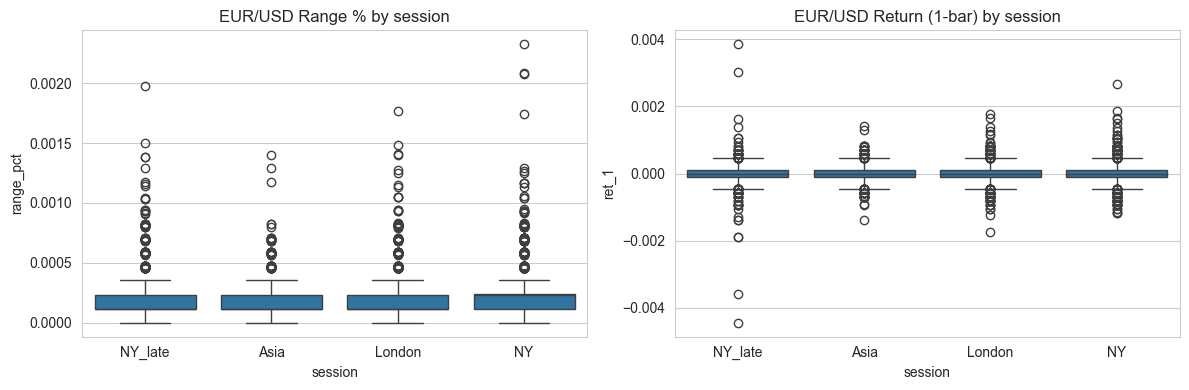

In [19]:
# ---- Price + time structure (5m primary) ---
five_ctx = add_time_context(five_min).copy()
five_ctx = add_returns_ranges(five_ctx)

display(five_ctx.describe().T[["mean", "std", "min", "max"]])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=five_ctx, x="session", y="range_pct", ax=ax[0])
sns.boxplot(data=five_ctx, x="session", y="ret_1", ax=ax[1])
ax[0].set_title("EUR/USD Range % by session")
ax[1].set_title("EUR/USD Return (1-bar) by session")
plt.tight_layout()
plt.show()


* We can also chart the price movements as well as the range and percentage change in return after 1 candlestick or (1 bar)

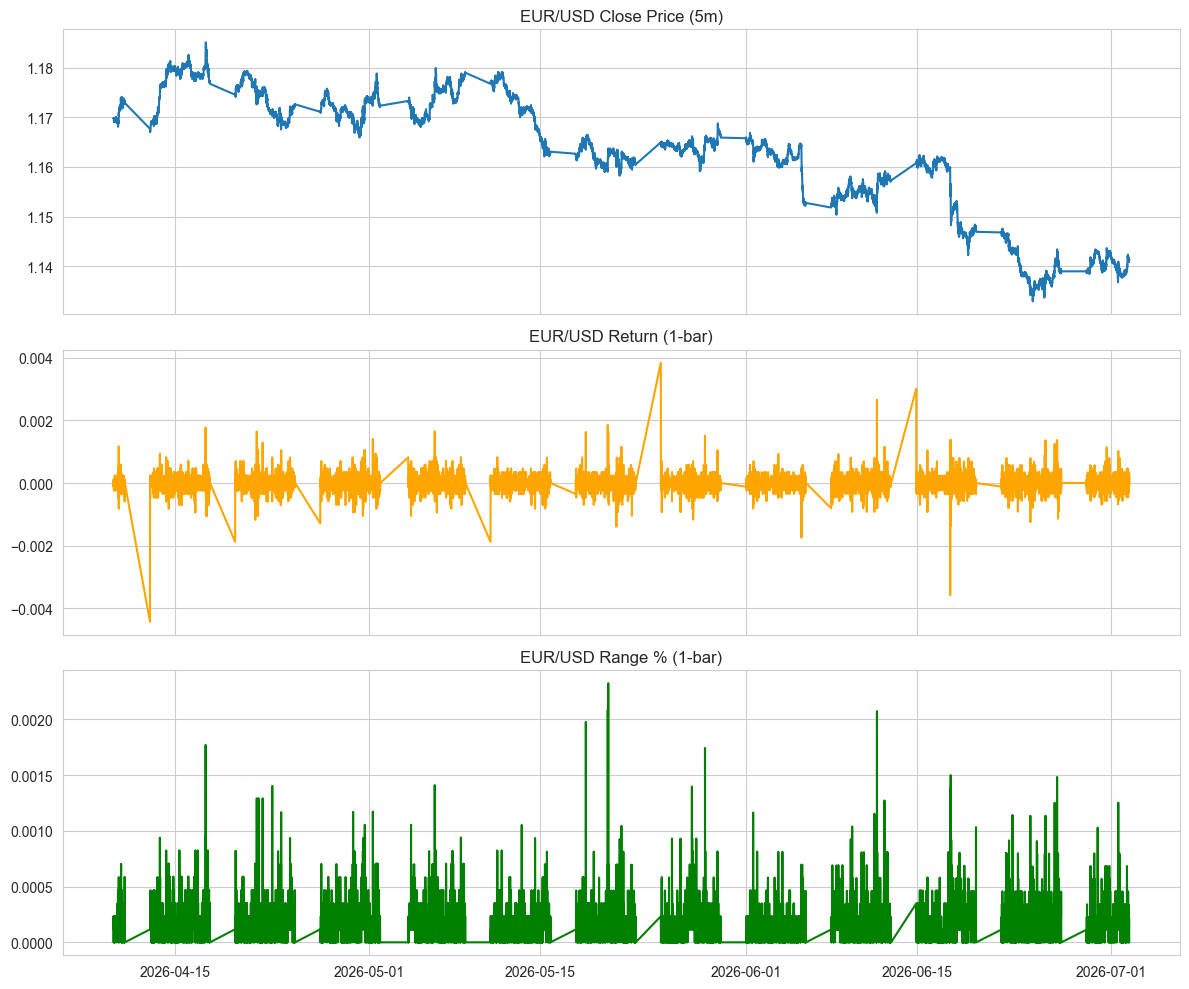

In [20]:
# Charting the close price with returns and range_pct
fig, ax = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
ax[0].plot(five_ctx.index, five_ctx["Close"], label="Close Price")
ax[0].set_title("EUR/USD Close Price (5m)")
ax[1].plot(five_ctx.index, five_ctx["ret_1"], label="Return (1-bar)", color='orange')
ax[1].set_title("EUR/USD Return (1-bar)")
ax[2].plot(five_ctx.index, five_ctx["range_pct"], label="Range %", color='green')
ax[2].set_title("EUR/USD Range % (1-bar)")
plt.tight_layout()
plt.show()

* We can now look at the average volatility by the hour and session

,mean,median
hour,,
0,0.000142,0.000117
1,0.000147,0.000117
2,0.000110,0.000116
3,0.000110,0.000116
4,0.000104,0.000116
5,0.000128,0.000117
6,0.000191,0.000118
7,0.000203,0.000228
8,0.000207,0.000227


,mean,median
session,,
Asia,0.000142,0.000117
London,0.000202,0.000118
NY,0.000223,0.000230
NY_late,0.000142,0.000116


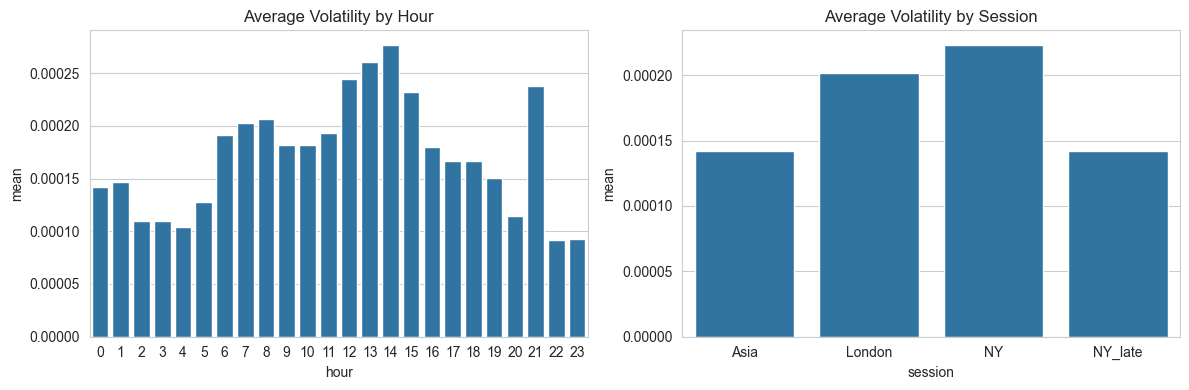

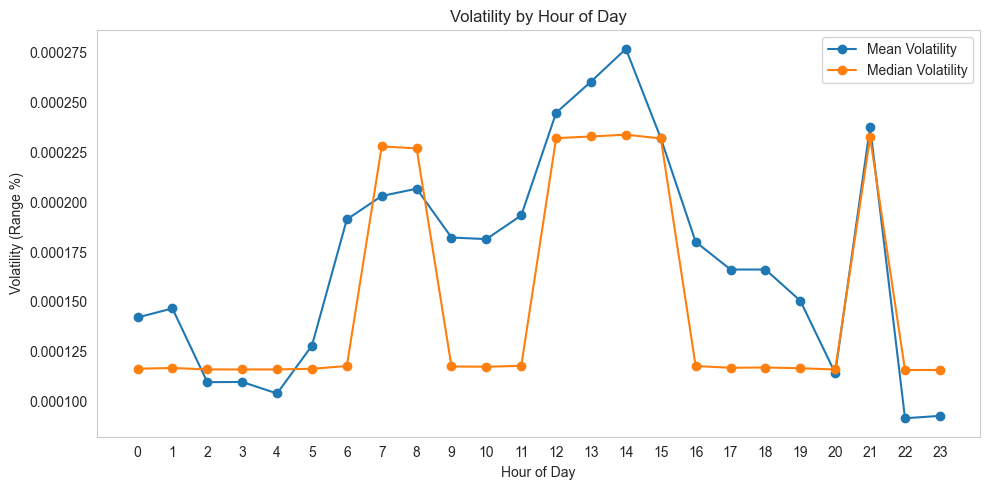

In [21]:
# Volatility by hour/session (Q1)
vol_hour = five_ctx.groupby("hour")["range_pct"].agg(["mean", "median"])
vol_sess = five_ctx.groupby("session")["range_pct"].agg(["mean", "median"])
display(vol_hour)
display(vol_sess)

# Plotting volatility by hour/session
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(x=vol_hour.index, y=vol_hour["mean"], ax=ax[0])
ax[0].set_title("Average Volatility by Hour")
sns.barplot(x=vol_sess.index, y=vol_sess["mean"], ax=ax[1])
ax[1].set_title("Average Volatility by Session")
plt.tight_layout()
plt.show()

# Plotting mean and median volatility by hour
plt.figure(figsize=(10, 5))
plt.plot(vol_hour.index, vol_hour["mean"], label="Mean Volatility", marker='o')
plt.plot(vol_hour.index, vol_hour["median"], label="Median Volatility", marker='o')
plt.title("Volatility by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Volatility (Range %)")
plt.xticks(vol_hour.index)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()




In [22]:



# --- 3) Mean reversion vs breakout/trend signals (Q2) ---
# Simple proxies: serial correlation, compression → breakout, trend slope
ac1 = five_ctx["ret_1"].autocorr(lag=1)
print("Lag-1 autocorr (ret_1):", ac1)

# Rolling volatility compression and subsequent move
five_ctx["vol_20"] = five_ctx["ret_1"].rolling(20).std()
five_ctx["next_range"] = five_ctx["hl_range"].shift(-1)
compression = five_ctx["vol_20"] < five_ctx["vol_20"].quantile(0.2)
print("Next-bar range mean after compression:", five_ctx.loc[compression, "next_range"].mean())
print("Next-bar range mean otherwise:", five_ctx.loc[~compression, "next_range"].mean())

# Trend persistence: slope of 21-bar EMA vs next return
five_ctx["ema_21"] = five_ctx["Close"].ewm(span=21).mean()
five_ctx["ema_slope"] = five_ctx["ema_21"].diff()
print("Next ret mean when ema_slope>0:", five_ctx.loc[five_ctx["ema_slope"] > 0, "ret_1"].shift(-1).mean())
print("Next ret mean when ema_slope<=0:", five_ctx.loc[five_ctx["ema_slope"] <= 0, "ret_1"].shift(-1).mean())

# --- 4) Typical ranges & feasible holds (Q3) ---
atr_14 = five_ctx["hl_range"].rolling(14).mean()
print("Median 5m ATR (pips):", (atr_14.median() * 10_000))

# Simple holding horizon: cumulative return over n bars
for n in [3, 6, 12]:
    five_ctx[f"ret_fwd_{n}"] = five_ctx["Close"].pct_change(periods=n).shift(-n)
    print(f"Median |ret| over {n} bars:", five_ctx[f"ret_fwd_{n}"].abs().median())



Lag-1 autocorr (ret_1): -0.03827446625516948
Next-bar range mean after compression: 0.00013119596100988841
Next-bar range mean otherwise: 0.00021681479632473574
Next ret mean when ema_slope>0: 6.140977008415e-05
Next ret mean when ema_slope<=0: -5.7825380210657245e-05
Median 5m ATR (pips): 1.833907195499965
Median |ret| over 3 bars: 0.00011782478655253392
Median |ret| over 6 bars: 0.000233154032869054
Median |ret| over 12 bars: 0.0003489160634886357


In [23]:
# --- 5) Economic calendar slice check (optional) ---
# Keep this cell non-blocking. The model can run even if the calendar CSV is unavailable.

rel = pd.DataFrame()

try:
    rel = pd.read_csv("data/economic calendar dataset/relevant_events.csv")
    if "date" in rel.columns:
        rel["date"] = pd.to_datetime(rel["date"], errors="coerce").astype(str)

    print("\nRelevant events schema:")
    print(rel.info())

    if "importance" in rel.columns:
        print("Events by importance:\n", rel["importance"].value_counts(dropna=False))
    else:
        print("Calendar file loaded, but no 'importance' column was found.")

except Exception as e:
    print("Calendar read skipped:", e)
    rel = pd.DataFrame(columns=["date", "time", "importance", "currency"])


Relevant events schema:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51634 entries, 0 to 51633
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        51634 non-null  object
 1   time        51634 non-null  object
 2   zone        51634 non-null  object
 3   currency    51634 non-null  object
 4   importance  51634 non-null  object
 5   event       51634 non-null  object
 6   actual      46448 non-null  object
 7   forecast    16679 non-null  object
 8   previous    46431 non-null  object
dtypes: object(9)
memory usage: 3.5+ MB
None
Events by importance:
 importance
low       33395
medium    14985
high       3254
Name: count, dtype: int64


### Price & Time Structure: Non-Technical EDA Summary

In the analysis above, we explored how EUR/USD prices move over time, focusing on patterns that repeat each day and across different market sessions (Asia, London, New York).

- **Hourly and Session Patterns:**  
    We grouped price data by hour and by trading session to see when the market is most active. The results show that volatility (how much prices move) is lowest during the Asia session and early morning hours, and highest during London and New York sessions. This matches common market wisdom: London and NY are busier, with bigger price swings.

- **Visualizing Price Moves:**  
    By plotting price changes and ranges, we can see periods of calm and periods of rapid movement. These visualizations help confirm that certain hours and sessions are more likely to see breakouts or trends, while others are more range-bound.

- **Relating to Business Questions:**  
    This EDA directly addresses key market behaviour questions:
    - **When is volatility highest or lowest?**  
        We found clear patterns by hour and session.
    - **Are there signs of mean reversion or breakouts?**  
        By looking at how price changes follow periods of low volatility, we can spot when breakouts are more likely.
    - **What trading horizons are feasible?**  
        The typical size of price moves and ranges by hour/session help set realistic expectations for trade duration and profit targets.

Overall, these insights guide when and how to trade, helping design strategies that fit the real behaviour of the EUR/USD market.

### Suggested Next Steps for EDA

1. **Feature Exploration:**
    - Examine the technical indicators generated (e.g., volatility, trend, momentum features) to identify which are most informative for price movement.
    - Visualize relationships between key features and future returns.

2. **Session-Based Analysis:**
    - Deepen the analysis of market behaviour by session (Asia, London, NY) using additional features like trend indicators and momentum.
    - Compare feature distributions and price action across sessions.

3. **Event Impact Analysis:**
    - Overlay economic news events from `relevant_events` onto price data to assess how high-impact events affect volatility and returns.
    - Quantify typical price moves before, during, and after major news releases.

4. **Regime Identification:**
    - Use clustering or unsupervised methods (e.g., KMeans, HDBSCAN) to identify different market regimes (trend, range, high-volatility).
    - Explore how strategy performance varies by regime.

5. **Correlation and Predictability:**
    - Calculate correlations between features and future returns to guide feature selection for modeling.
    - Test simple predictive rules (e.g., volatility compression → breakout) for statistical significance.

6. **Risk & Money Management Insights:**
    - Analyze stop-loss and take-profit distances relative to typical volatility and spread.
    - Assess how risk parameters would have performed historically.

7. **Data Quality Checks:**
    - Check for outliers, duplicate timestamps, and any remaining data quality issues.
    - Ensure time alignment between price and event data.

Top correlated features with Close price:
Adj Close              1.000000
Close                  1.000000
others_cr              1.000000
High                   0.999935
Low                    0.999930
Open                   0.999851
trend_ichimoku_conv    0.999557
trend_ema_fast         0.999540
momentum_kama          0.999491
volatility_kcc         0.999442
Name: Close, dtype: float64


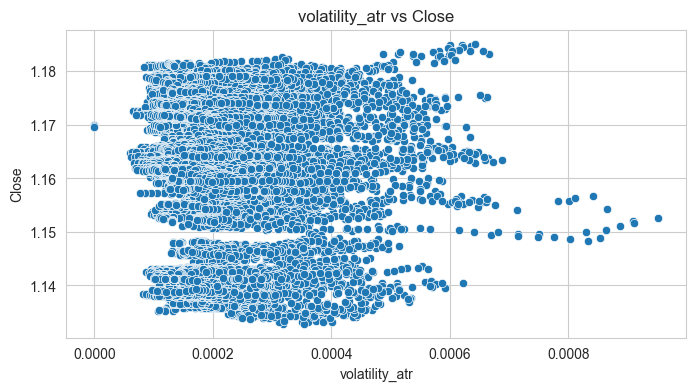

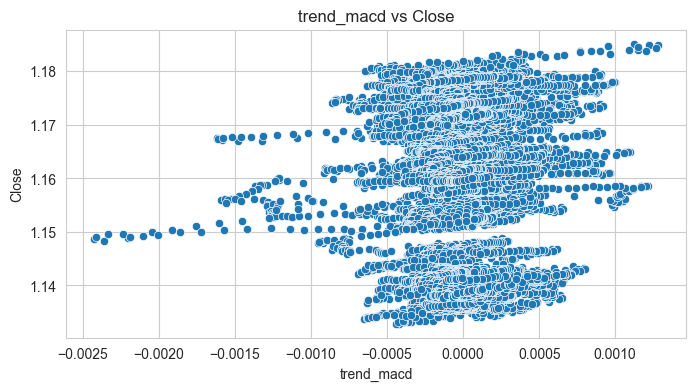

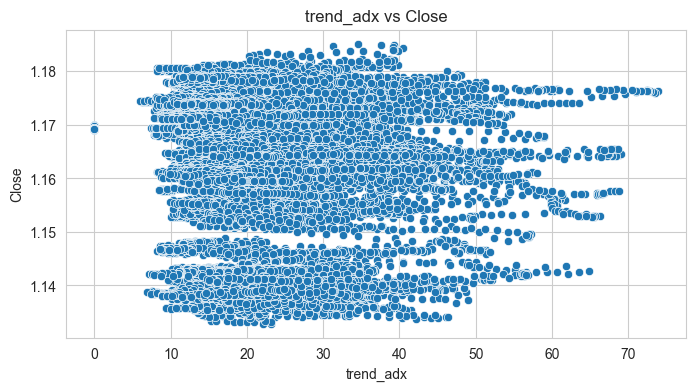

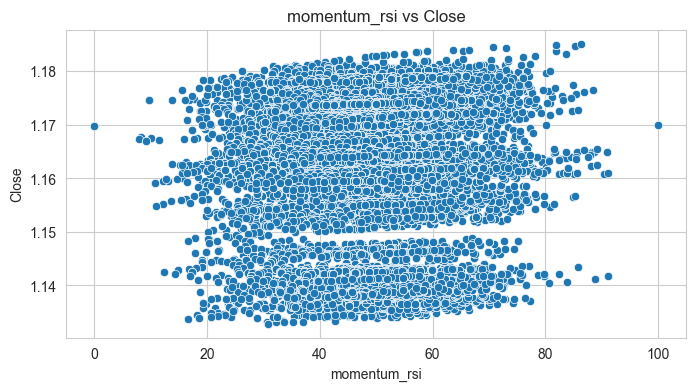

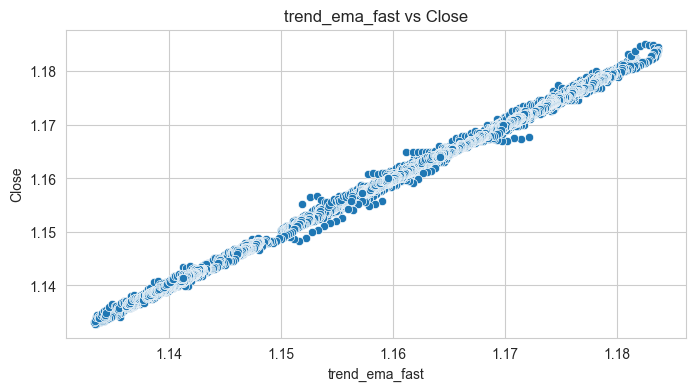

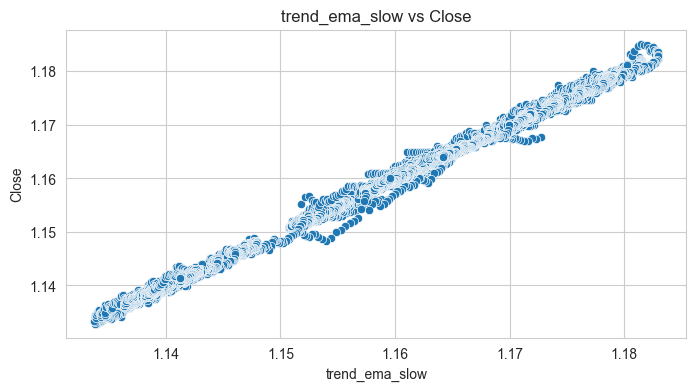

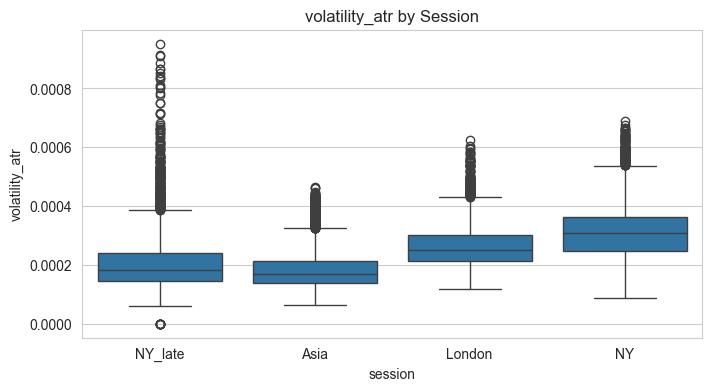

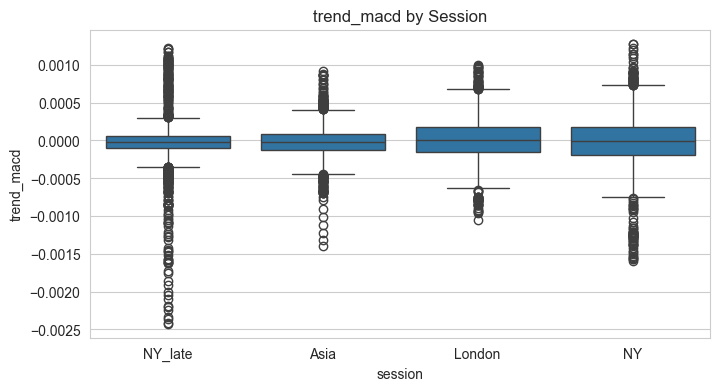

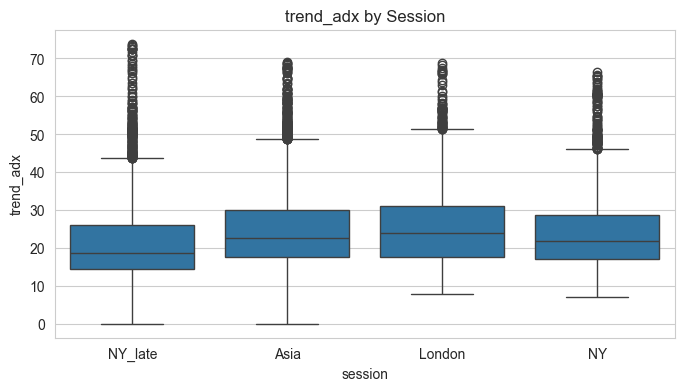

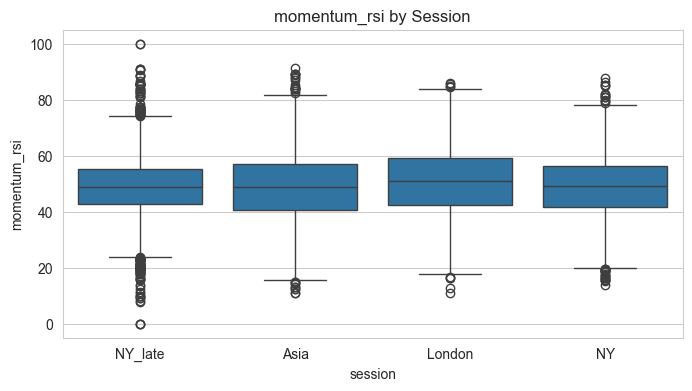

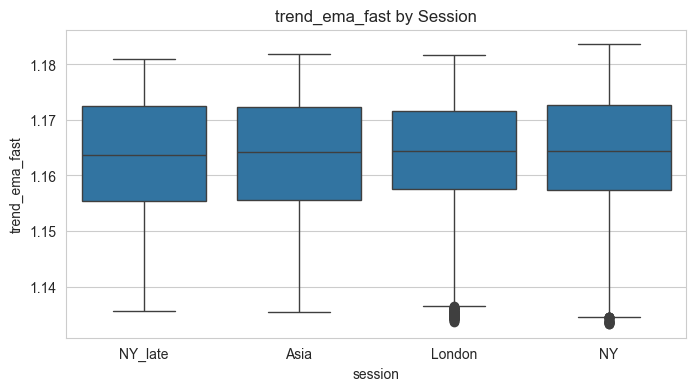

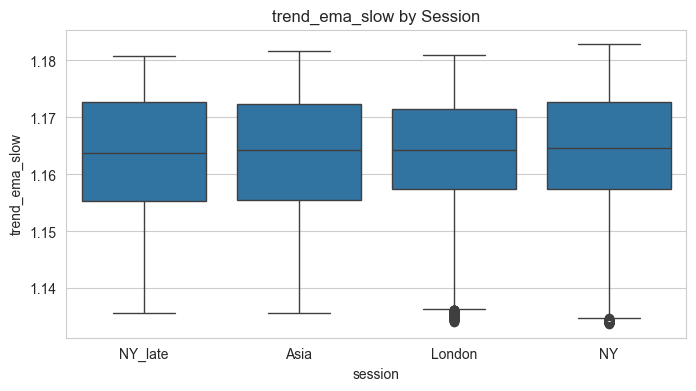

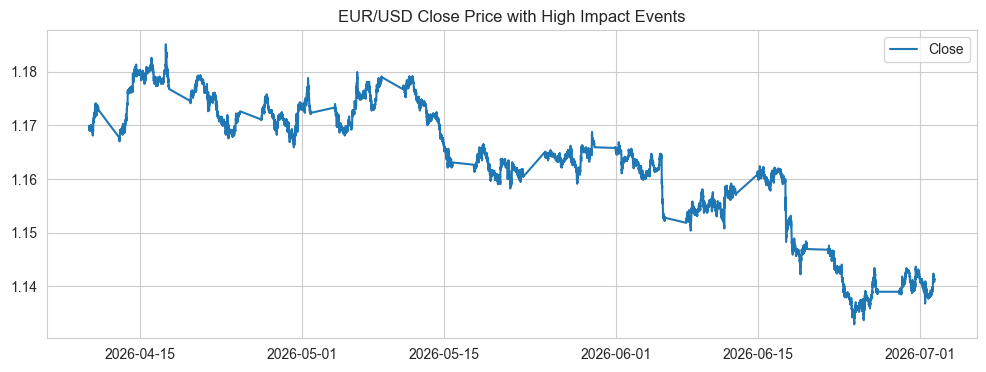

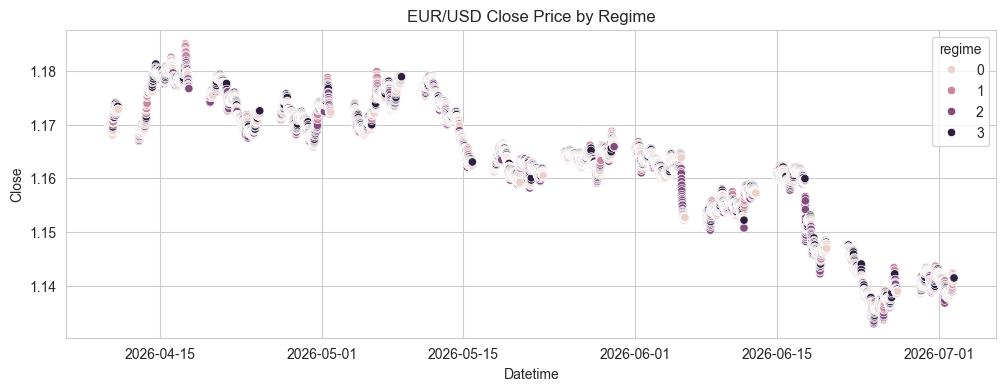


Correlation with ret_fwd_1:
ret_fwd_1         1.000000
trend_adx         0.007567
volatility_atr   -0.001781
trend_ema_slow   -0.004834
trend_ema_fast   -0.004985
trend_macd       -0.007303
momentum_rsi     -0.033284
Name: ret_fwd_1, dtype: float64

Correlation with ret_fwd_3:
ret_fwd_3         1.000000
trend_adx         0.013237
trend_macd       -0.007310
trend_ema_slow   -0.008406
trend_ema_fast   -0.008553
volatility_atr   -0.011212
momentum_rsi     -0.034166
Name: ret_fwd_3, dtype: float64

Correlation with ret_fwd_6:
ret_fwd_6         1.000000
trend_adx         0.017948
trend_macd       -0.005116
trend_ema_slow   -0.011943
trend_ema_fast   -0.012038
volatility_atr   -0.022504
momentum_rsi     -0.033292
Name: ret_fwd_6, dtype: float64

Correlation with ret_fwd_12:
ret_fwd_12        1.000000
trend_adx         0.021099
trend_macd       -0.006060
trend_ema_slow   -0.016723
trend_ema_fast   -0.016833
volatility_atr   -0.031430
momentum_rsi     -0.034333
Name: ret_fwd_12, dtype: float6

count    16819.000000
mean         1.162855
std          0.012236
min          1.132888
25%          1.156738
50%          1.164280
75%          1.172333
max          1.185115
Name: Close, dtype: float64

In [24]:


# 1. Feature Exploration: Correlation and importance of technical indicators
numeric_corr_df = five_min.select_dtypes(include=[np.number])
if "Close" in numeric_corr_df.columns:
    feature_corr = numeric_corr_df.corr()["Close"].sort_values(ascending=False)
    print("Top correlated features with Close price:")
    print(feature_corr.head(10))

selected_features = [
    "volatility_atr",
    "trend_macd",
    "trend_adx",
    "momentum_rsi",
    "trend_ema_fast",
    "trend_ema_slow",
]
selected_features = [feat for feat in selected_features if feat in five_min.columns]

if not selected_features:
    print("Selected TA features were not found. Re-run the TA feature cell above.")
else:
    # Visualize relationships between selected features and current price
    for feat in selected_features:
        plt.figure(figsize=(8, 4))
        sns.scatterplot(x=five_min[feat], y=five_min["Close"])
        plt.title(f"{feat} vs Close")
        plt.show()

    # 2. Session-Based Analysis: Compare feature distributions across sessions
    five_ctx = add_time_context(five_min)
    for feat in selected_features:
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=five_ctx["session"], y=five_ctx[feat])
        plt.title(f"{feat} by Session")
        plt.show()

# 3. Event Impact Analysis: Overlay high-impact news events if calendar data exists
if {"date", "time", "importance"}.issubset(rel.columns) and not rel.empty:
    rel = rel.copy()
    rel["datetime"] = pd.to_datetime(
        rel["date"].astype(str) + " " + rel["time"].astype(str),
        errors="coerce",
        utc=True,
    )

    high_impact = rel[rel["importance"].astype(str).str.lower().eq("high")]
    event_times = high_impact["datetime"].dropna()

    event_index = pd.DatetimeIndex(event_times)
    price_index_utc = pd.DatetimeIndex(five_min.index)
    if price_index_utc.tz is None:
        price_index_utc = price_index_utc.tz_localize("UTC")
    else:
        price_index_utc = price_index_utc.tz_convert("UTC")

    five_min["is_high_impact_event"] = price_index_utc.isin(event_index)

    plt.figure(figsize=(12, 4))
    plt.plot(five_min.index, five_min["Close"], label="Close")
    event_mask = five_min["is_high_impact_event"].to_numpy()
    if event_mask.any():
        plt.scatter(
            five_min.index[event_mask],
            five_min.loc[event_mask, "Close"],
            color="red",
            label="High Impact Event",
            marker="X",
            s=10,
        )
    plt.legend()
    plt.title("EUR/USD Close Price with High Impact Events")
    plt.show()
else:
    print("Event impact plot skipped because calendar data is unavailable or incomplete.")

# 4. Regime Identification: Simple clustering on volatility and trend features
regime_features = [
    feat for feat in ["volatility_atr", "trend_macd", "trend_adx", "momentum_rsi"]
    if feat in five_min.columns
]

if len(regime_features) >= 2:
    X = five_min[regime_features].fillna(0)
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X)
    kmeans = KMeans(n_clusters=4, random_state=42, n_init="auto")
    five_min["regime"] = kmeans.fit_predict(X_scaled)

    plt.figure(figsize=(12, 4))
    sns.scatterplot(x=five_min.index, y=five_min["Close"], hue=five_min["regime"], legend="full")
    plt.title("EUR/USD Close Price by Regime")
    plt.show()
else:
    print("Regime clustering skipped because fewer than two required TA features are available.")

# 5. Correlation and Predictability: Correlation with future returns
if selected_features:
    for n in [1, 3, 6, 12]:
        five_min[f"ret_fwd_{n}"] = five_min["Close"].pct_change(periods=n).shift(-n)
        corr = (
            five_min[selected_features + [f"ret_fwd_{n}"]]
            .corr()[f"ret_fwd_{n}"]
            .sort_values(ascending=False)
        )
        print(f"\nCorrelation with ret_fwd_{n}:")
        print(corr)

# 6. Risk & Money Management Insights: Typical stop-loss/take-profit distances
if "volatility_atr" in five_min.columns:
    atr_median = five_min["volatility_atr"].median()
    print(f"Median ATR (stop-loss guide, pips): {atr_median * 10000:.2f}")
    print(f"Typical take-profit (2x ATR, pips): {atr_median * 2 * 10000:.2f}")

# 7. Data Quality Checks: Outliers, duplicates, time alignment
print("Duplicate timestamps:", five_min.index.duplicated().sum())
print("Outlier check (Close):")
display(five_min["Close"].describe())

### EDA Context & Evaluation

The exploratory data analysis (EDA) above systematically investigates the EUR/USD 5-minute dataset, enriched with technical indicators and event overlays. The workflow covers:

- **Feature Exploration:**  
    Key technical indicators (volatility, trend, momentum) are correlated with price and visualized, helping identify which features may be most predictive for modeling.

- **Session-Based Analysis:**  
    Feature distributions are compared across market sessions (Asia, London, NY), confirming session-dependent volatility and price behaviour—crucial for intraday strategy design.

- **Event Impact Analysis:**  
    High-impact economic news events are overlaid on price data, visually and statistically highlighting their effect on volatility and returns. This supports the business constraint of avoiding trading during unstable periods.

- **Regime Identification:**  
    Clustering (KMeans) segments the market into regimes based on volatility and trend features, providing a foundation for regime-adaptive strategies.

- **Correlation & Predictability:**  
    Forward returns are correlated with selected features, quantifying their predictive power and guiding feature selection for ML models.

- **Risk & Money Management:**  
    ATR-based stop-loss and take-profit distances are calculated, aligning risk management parameters with observed market volatility.

- **Data Quality Checks:**  
    Outliers, duplicates, and time alignment are checked to ensure robust downstream modeling.

**Evaluation:**  
The EDA is thorough and directly addresses the analytical and business questions posed earlier. It validates key market hypotheses (session effects, event impacts, regime shifts) and provides actionable insights for feature engineering, risk management, and strategy logic. The approach is systematic, reproducible, and well-aligned with the project’s objectives of building a robust, ML-driven FX trading framework.

## 3) Data Preparation

### 3.1 Dropping meaningless columns. (Volume)

In [25]:


# Dropping volume and volume based columns as they contain zeros and are not useful for our analysis
cols_to_drop = [col for col in five_ctx.columns if 'volume' in col.lower()]
five_ctx = five_ctx.drop(columns=cols_to_drop)

# dropping other zero columns
zero_cols = [col for col in five_ctx.columns if (five_ctx[col] == 0).all()]
five_ctx = five_ctx.drop(columns=zero_cols)

five_ctx

,Adj Close,Close,High,Low,Open,volatility_bbm,volatility_bbh,volatility_bbl,volatility_bbw,volatility_bbp,...,momentum_ppo,momentum_ppo_signal,momentum_ppo_hist,momentum_kama,others_dr,others_dlr,others_cr,hour,dow,session
Datetime,,,,,,,,,,,,,,,,,,,,,
2026-04-09 23:00:00+00:00,1.169864,1.169864,1.169864,1.169727,1.169727,1.169864,1.169864,1.169864,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.169864,0.000000,0.000000,0.000000,23,3,NY_late
2026-04-09 23:05:00+00:00,1.169864,1.169864,1.170001,1.169727,1.169864,1.169864,1.169864,1.169864,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.169864,0.000000,0.000000,0.000000,23,3,NY_late
2026-04-09 23:10:00+00:00,1.169727,1.169727,1.169864,1.169727,1.169864,1.169819,1.169948,1.169690,0.022059,0.146447,...,-0.000933,-0.000187,-0.000747,1.169802,-0.011698,-0.011699,-0.011698,23,3,NY_late
2026-04-09 23:15:00+00:00,1.169727,1.169727,1.169727,1.169727,1.169727,1.169796,1.169933,1.169659,0.023398,0.250000,...,-0.001654,-0.000480,-0.001174,1.169769,0.000000,0.000000,-0.011698,23,3,NY_late
2026-04-09 23:20:00+00:00,1.169727,1.169727,1.169727,1.169727,1.169727,1.169782,1.169916,1.169648,0.022925,0.295876,...,-0.002199,-0.000824,-0.001375,1.169750,0.000000,0.000000,-0.011698,23,3,NY_late
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-02 10:55:00+00:00,1.141292,1.141292,1.141422,1.141162,1.141422,1.141259,1.141847,1.140672,0.102967,0.527588,...,-0.005891,-0.003039,-0.002852,1.141150,0.011407,0.011407,-2.442372,10,3,London
2026-07-02 11:00:00+00:00,1.141292,1.141292,1.141422,1.141162,1.141422,1.141240,1.141795,1.140685,0.097267,0.546817,...,-0.004421,-0.003315,-0.001106,1.141152,0.000000,0.000000,-2.442372,11,3,London
2026-07-02 11:05:00+00:00,1.141162,1.141162,1.141292,1.141032,1.141292,1.141233,1.141789,1.140678,0.097349,0.435464,...,-0.004129,-0.003478,-0.000651,1.141153,-0.011406,-0.011407,-2.453500,11,3,London


### 3.2 Converting to a 3 class ATR Target

In [26]:

# ============================================================
# 3-CLASS ATR-BASED TRADING TARGET
# Long / Short / No-Trade
# ============================================================

model_df = five_ctx.copy().sort_index()

horizon = 6          # 6 bars = 30 minutes on 5m data
atr_mult = 0.75      # required move beyond noise
pip_cost = 0.00010   # 1 pip estimated round-trip cost

# Forward return
model_df[f"ret_fwd_{horizon}"] = (
    model_df["Close"].shift(-horizon) / model_df["Close"] - 1
)

# ATR as percentage of price
model_df["atr_pct"] = model_df["volatility_atr"] / model_df["Close"]

# Cost as percentage
model_df["cost_pct"] = pip_cost / model_df["Close"]

# Dynamic threshold
model_df["trade_threshold"] = model_df["cost_pct"] + atr_mult * model_df["atr_pct"]

# Target:
# 0 = Short
# 1 = No Trade
# 2 = Long
model_df["y_3cls"] = 1

model_df.loc[
    model_df[f"ret_fwd_{horizon}"] > model_df["trade_threshold"],
    "y_3cls"
] = 2

model_df.loc[
    model_df[f"ret_fwd_{horizon}"] < -model_df["trade_threshold"],
    "y_3cls"
] = 0

print(model_df["y_3cls"].value_counts(normalize=True).sort_index())



y_3cls
0    0.275165
1    0.475474
2    0.249361
Name: proportion, dtype: float64


### 3.3 Coverting features to stationary versions

In [27]:

# ============================================================
# STATIONARY / RELATIVE FEATURES
# ============================================================

model_df["ema_spread_pct"] = (
    model_df["trend_ema_fast"] - model_df["trend_ema_slow"]
) / model_df["trend_ema_slow"]

model_df["macd_signal_diff"] = (
    model_df["trend_macd"] - model_df["trend_macd_signal"]
)

model_df["macd_direction"] = np.sign(model_df["macd_signal_diff"])

model_df["close_to_ema_fast_atr"] = (
    model_df["Close"] - model_df["trend_ema_fast"]
) / model_df["volatility_atr"]

model_df["range_atr"] = (
    model_df["High"] - model_df["Low"]
) / model_df["volatility_atr"]

model_df["body_atr"] = (
    model_df["Close"] - model_df["Open"]
).abs() / model_df["volatility_atr"]

model_df["ret_1"] = model_df["Close"].pct_change()
model_df["ret_3"] = model_df["Close"].pct_change(3)
model_df["ret_6"] = model_df["Close"].pct_change(6)

model_df["volatility_ratio"] = (
    model_df["volatility_atr"] / model_df["volatility_atr"].rolling(50).median()
)

model_df = model_df.replace([np.inf, -np.inf], np.nan)

### 3.4 Feature selection

In [28]:


# ============================================================
# FEATURE SELECTION — REMOVE LEAKAGE AND NON-STATIONARY COLUMNS
# ============================================================

leakage_cols = [
    c for c in model_df.columns
    if c.startswith("ret_fwd_")
]

drop_cols = [
    "Open", "High", "Low", "Close", "Adj Close",
    "Volume",
    "y_3cls",
    "trade_threshold",
    "cost_pct",
    "next_range",
    "y_cls",
    "y_reg",
] + leakage_cols

candidate_features = [
    c for c in model_df.columns
    if c not in drop_cols
]

categorical_features = ["session"]

numeric_features = [
    c for c in candidate_features
    if c not in categorical_features
    and pd.api.types.is_numeric_dtype(model_df[c])
]

model_df = model_df.dropna(
    subset=numeric_features + categorical_features + ["y_3cls", f"ret_fwd_{horizon}"]
)

print("Numeric features:", len(numeric_features))
print("Categorical features:", categorical_features)
print("Target distribution:")
print(model_df["y_3cls"].value_counts(normalize=True).sort_index())


Numeric features: 86
Categorical features: ['session']
Target distribution:
y_3cls
0    0.275173
1    0.475424
2    0.249403
Name: proportion, dtype: float64


### 3.5 Preprocessing pipeline

In [29]:
# --- Creating ETL pipelines for preprocessing ---

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

### 3.6 Train / Test split (time-based)

In [30]:
# ============================================================
# TRAIN / VALIDATION / TEST SPLIT — STRICT TIME ORDER
# ============================================================

X_all = model_df[numeric_features + categorical_features]
y_all = model_df["y_3cls"]

n = len(model_df)
test_size = int(n * 0.20)

if test_size < 1:
    raise ValueError("Not enough rows to create a test set. Add more data or reduce test_size fraction.")

trainval_df = model_df.iloc[:-test_size].copy()
df_test = model_df.iloc[-test_size:].copy()

X_trainval = X_all.iloc[:-test_size]
y_trainval = y_all.iloc[:-test_size]

X_test = X_all.iloc[-test_size:]
y_test = y_all.iloc[-test_size:]

# This validation block is used for threshold/strategy selection only.
# The final untouched test set is not used to choose the strategy.
validation_fraction = 0.25
validation_size = max(int(len(X_trainval) * validation_fraction), 1)

if len(X_trainval) - validation_size < 100:
    validation_size = max(int(len(X_trainval) * 0.20), 1)

if len(X_trainval) - validation_size < 50:
    raise ValueError(
        "Not enough train/validation rows after splitting. "
        "Use more historical data or reduce the validation/test fractions."
    )

X_train_core = X_trainval.iloc[:-validation_size]
y_train_core = y_trainval.iloc[:-validation_size]
X_val = X_trainval.iloc[-validation_size:]
y_val = y_trainval.iloc[-validation_size:]

df_train_core = trainval_df.iloc[:-validation_size].copy()
df_val = trainval_df.iloc[-validation_size:].copy()

print("Full modelling rows:", model_df.shape)
print("Train core:", X_train_core.shape, df_train_core.index.min(), "→", df_train_core.index.max())
print("Validation:", X_val.shape, df_val.index.min(), "→", df_val.index.max())
print("Train+Validation:", X_trainval.shape, trainval_df.index.min(), "→", trainval_df.index.max())
print("Final untouched test:", X_test.shape, df_test.index.min(), "→", df_test.index.max())

print("\nTarget distribution — train core:")
print(y_train_core.value_counts(normalize=True).sort_index())
print("\nTarget distribution — validation:")
print(y_val.value_counts(normalize=True).sort_index())
print("\nTarget distribution — test:")
print(y_test.value_counts(normalize=True).sort_index())


Full modelling rows: (16764, 96)
Train core: (10059, 87) 2026-04-10 03:05:00+00:00 → 2026-05-29 20:30:00+00:00
Validation: (3353, 87) 2026-05-29 20:35:00+00:00 → 2026-06-16 16:25:00+00:00
Train+Validation: (13412, 87) 2026-04-10 03:05:00+00:00 → 2026-06-16 16:25:00+00:00
Final untouched test: (3352, 87) 2026-06-16 16:30:00+00:00 → 2026-07-02 10:45:00+00:00

Target distribution — train core:
y_3cls
0    0.268416
1    0.484144
2    0.247440
Name: proportion, dtype: float64

Target distribution — validation:
y_3cls
0    0.275574
1    0.465851
2    0.258574
Name: proportion, dtype: float64

Target distribution — test:
y_3cls
0    0.295048
1    0.458831
2    0.246122
Name: proportion, dtype: float64


## 4) Data Modelling

### 4.1 XGBClassifier — 3-Class ATR-Aware Model

This section treats the XGB model as the canonical 3-class ATR-aware research model. The model predicts **Short / No Trade / Long**, ranks directional confidence, chooses the confidence cutoff and execution filters on validation only, then evaluates the selected strategy once on the untouched test set.


In [31]:
# ============================================================
# 4.1 RESEARCH DATASET CHECKS, FEATURES, SPLIT, PREPROCESSING
# ============================================================



if "model_df" not in globals():
    raise NameError("model_df must be created by the earlier preprocessing cells before running section 4.1.")

model_df = model_df.copy().sort_index()

horizon = globals().get("horizon", 6)
pip_cost = globals().get("pip_cost", 0.0001)
atr_mult = globals().get("atr_mult", 0.75)
ret_col = f"ret_fwd_{horizon}"

print(f"Using horizon={horizon}, pip_cost={pip_cost}, atr_mult={atr_mult}")

if ret_col not in model_df.columns:
    model_df[ret_col] = model_df["Close"].shift(-horizon) / model_df["Close"] - 1

if "atr_pct" not in model_df.columns:
    model_df["atr_pct"] = model_df["volatility_atr"] / model_df["Close"]

if "cost_pct" not in model_df.columns:
    model_df["cost_pct"] = pip_cost / model_df["Close"]

if "trade_threshold" not in model_df.columns:
    model_df["trade_threshold"] = model_df["cost_pct"] + atr_mult * model_df["atr_pct"]

target_is_valid = (
    "y_3cls" in model_df.columns
    and set(pd.Series(model_df["y_3cls"]).dropna().unique()).issubset({0, 1, 2})
)

if not target_is_valid:
    model_df["y_3cls"] = 1
    model_df.loc[model_df[ret_col] > model_df["trade_threshold"], "y_3cls"] = 2
    model_df.loc[model_df[ret_col] < -model_df["trade_threshold"], "y_3cls"] = 0
    print("Recreated y_3cls target from ATR-aware threshold.")
else:
    print("Using existing y_3cls target.")

stationary_requirements = [
    "trend_ema_fast", "trend_ema_slow", "trend_macd", "trend_macd_signal",
    "volatility_atr", "Open", "High", "Low", "Close"
]
missing_stationary_inputs = [c for c in stationary_requirements if c not in model_df.columns]
if missing_stationary_inputs:
    raise KeyError(f"Missing columns needed for stationary features: {missing_stationary_inputs}")

if "ema_spread_pct" not in model_df.columns:
    model_df["ema_spread_pct"] = (model_df["trend_ema_fast"] - model_df["trend_ema_slow"]) / model_df["trend_ema_slow"]

if "macd_signal_diff" not in model_df.columns:
    model_df["macd_signal_diff"] = model_df["trend_macd"] - model_df["trend_macd_signal"]

if "macd_direction" not in model_df.columns:
    model_df["macd_direction"] = np.sign(model_df["macd_signal_diff"])

if "close_to_ema_fast_atr" not in model_df.columns:
    model_df["close_to_ema_fast_atr"] = (model_df["Close"] - model_df["trend_ema_fast"]) / model_df["volatility_atr"]

if "range_atr" not in model_df.columns:
    model_df["range_atr"] = (model_df["High"] - model_df["Low"]) / model_df["volatility_atr"]

if "body_atr" not in model_df.columns:
    model_df["body_atr"] = (model_df["Close"] - model_df["Open"]).abs() / model_df["volatility_atr"]

for bars in [1, 3, 6]:
    col = f"ret_{bars}"
    if col not in model_df.columns:
        model_df[col] = model_df["Close"].pct_change(bars)

if "volatility_ratio" not in model_df.columns:
    rolling_atr_median = model_df["volatility_atr"].rolling(50).median()
    model_df["volatility_ratio"] = model_df["volatility_atr"] / rolling_atr_median

model_df = model_df.replace([np.inf, -np.inf], np.nan)

raw_price_cols = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
leakage_cols = [c for c in model_df.columns if c.startswith("ret_fwd_")]
target_eval_cols = [
    "y_3cls", "y_cls", "y_reg", "next_range",
    "signal", "signal_raw", "gross_ret", "net_ret", "equity", "trade_cost",
    "cost_pct", "trade_threshold", "p_short", "p_hold", "p_long",
    "trade_confidence", "short_confidence", "long_confidence"
]

drop_cols = set(raw_price_cols + leakage_cols + target_eval_cols)

if "session" not in model_df.columns:
    raise KeyError("The categorical feature 'session' is required for session-aware strategy filters.")

categorical_features = ["session"]
candidate_features = [c for c in model_df.columns if c not in drop_cols]
numeric_features = [
    c for c in candidate_features
    if c not in categorical_features and pd.api.types.is_numeric_dtype(model_df[c])
]

feature_cols = numeric_features + categorical_features
forbidden_features = sorted(set(feature_cols).intersection(drop_cols))
if forbidden_features:
    raise ValueError(f"Leakage or raw price columns entered the feature matrix: {forbidden_features}")

required_subset = feature_cols + ["y_3cls", ret_col]
model_df = model_df.dropna(subset=required_subset).copy()

X_all = model_df[feature_cols]
y_all = model_df["y_3cls"].astype(int)

test_size = int(len(model_df) * 0.20)
if test_size <= 0 or len(model_df) - test_size <= 0:
    raise ValueError("Not enough rows for a chronological 80/20 train/test split.")

trainval_df = model_df.iloc[:-test_size].copy()
df_test = model_df.iloc[-test_size:].copy()

X_trainval = X_all.iloc[:-test_size].copy()
y_trainval = y_all.iloc[:-test_size].copy()
X_test = X_all.iloc[-test_size:].copy()
y_test = y_all.iloc[-test_size:].copy()

# Validation is carved from the tail of the train+validation block.
# It is used to choose thresholds and strategy filters before touching the final test set.
validation_fraction = 0.25
validation_size = max(int(len(X_trainval) * validation_fraction), 1)

if len(X_trainval) - validation_size < 100:
    validation_size = max(int(len(X_trainval) * 0.20), 1)

if len(X_trainval) - validation_size < 50:
    raise ValueError(
        "Not enough train/validation rows after splitting. "
        "Use more historical data or reduce the validation/test fractions."
    )

X_train_core = X_trainval.iloc[:-validation_size].copy()
y_train_core = y_trainval.iloc[:-validation_size].copy()
X_val = X_trainval.iloc[-validation_size:].copy()
y_val = y_trainval.iloc[-validation_size:].copy()

df_train_core = trainval_df.iloc[:-validation_size].copy()
df_val = trainval_df.iloc[-validation_size:].copy()

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

print("Numeric features:", len(numeric_features))
print(numeric_features)
print("Categorical features:", categorical_features)
print("Train core:", X_train_core.shape, df_train_core.index.min(), "→", df_train_core.index.max())
print("Validation:", X_val.shape, df_val.index.min(), "→", df_val.index.max())
print("Train+Val:", X_trainval.shape, trainval_df.index.min(), "→", trainval_df.index.max())
print("Final untouched test:", X_test.shape, df_test.index.min(), "→", df_test.index.max())
print("Target distribution:")
print(model_df["y_3cls"].value_counts(normalize=True).sort_index())


Using horizon=6, pip_cost=0.0001, atr_mult=0.75
Using existing y_3cls target.
Numeric features: 86
['volatility_bbm', 'volatility_bbh', 'volatility_bbl', 'volatility_bbw', 'volatility_bbp', 'volatility_bbhi', 'volatility_bbli', 'volatility_kcc', 'volatility_kch', 'volatility_kcl', 'volatility_kcw', 'volatility_kcp', 'volatility_kchi', 'volatility_kcli', 'volatility_dcl', 'volatility_dch', 'volatility_dcm', 'volatility_dcw', 'volatility_dcp', 'volatility_atr', 'volatility_ui', 'trend_macd', 'trend_macd_signal', 'trend_macd_diff', 'trend_sma_fast', 'trend_sma_slow', 'trend_ema_fast', 'trend_ema_slow', 'trend_vortex_ind_pos', 'trend_vortex_ind_neg', 'trend_vortex_ind_diff', 'trend_trix', 'trend_mass_index', 'trend_dpo', 'trend_kst', 'trend_kst_sig', 'trend_kst_diff', 'trend_ichimoku_conv', 'trend_ichimoku_base', 'trend_ichimoku_a', 'trend_ichimoku_b', 'trend_stc', 'trend_adx', 'trend_adx_pos', 'trend_adx_neg', 'trend_cci', 'trend_visual_ichimoku_a', 'trend_visual_ichimoku_b', 'trend_aroon

### Trading-Aware Validation Helpers

These helpers keep signal generation, cost accounting, profit factor, drawdown, cooldown/no-overlap rules, hour filters, and zero-trade handling consistent across validation, test, threshold sweep, cost stress, walk-forward validation, and the final Backtrader execution test.


In [32]:
# ============================================================
# STRATEGY HELPERS — NON-OVERLAP, FIXED CUTOFFS, ROBUST METRICS
# ============================================================

ALL_CLASSES = np.array([0, 1, 2], dtype=int)
CLASS_NAMES = {0: "Short", 1: "No Trade", 2: "Long"}


def normalize_3class_proba(proba, classes=None):
    """
    Force predict_proba output into columns [p_short, p_hold, p_long].
    This prevents downstream shape errors if a fold was trained with a missing class.
    """
    proba = np.asarray(proba)

    if proba.ndim != 2:
        raise ValueError("predict_proba output must be a 2D array.")

    if classes is None:
        if proba.shape[1] != 3:
            raise ValueError(
                f"Expected 3 probability columns, got {proba.shape[1]}. "
                "Pass the model classes to normalize_3class_proba."
            )
        return proba

    classes = np.asarray(classes).astype(int)
    aligned = np.zeros((proba.shape[0], 3), dtype=float)

    for j, cls in enumerate(classes):
        if cls in ALL_CLASSES and j < proba.shape[1]:
            aligned[:, int(cls)] = proba[:, j]

    row_sum = aligned.sum(axis=1, keepdims=True)
    missing_rows = row_sum.squeeze() <= 0

    if missing_rows.any():
        aligned[missing_rows, 1] = 1.0
        row_sum = aligned.sum(axis=1, keepdims=True)

    return aligned / row_sum


def build_probability_frame(proba, index, classes=None):
    proba = normalize_3class_proba(proba, classes=classes)

    proba_frame = pd.DataFrame(
        proba,
        columns=["p_short", "p_hold", "p_long"],
        index=index,
    )

    proba_frame["trade_confidence"] = proba_frame[["p_short", "p_long"]].max(axis=1)
    proba_frame["short_confidence"] = proba_frame["p_short"]
    proba_frame["long_confidence"] = proba_frame["p_long"]

    return proba_frame


def build_signals_with_fixed_cutoff(proba, index, cutoff, classes=None):
    """
    Build long/short candidate signals using a cutoff that was chosen elsewhere.
    Important: for final test evaluation, the cutoff should come from validation data,
    not from the test probability distribution.
    """
    proba_frame = build_probability_frame(proba, index=index, classes=classes)
    signal_raw = np.zeros(len(proba_frame), dtype=int)

    long_mask = (
        (proba_frame["trade_confidence"] >= cutoff)
        & (proba_frame["p_long"] > proba_frame["p_short"])
    )
    short_mask = (
        (proba_frame["trade_confidence"] >= cutoff)
        & (proba_frame["p_short"] > proba_frame["p_long"])
    )

    signal_raw[long_mask.to_numpy()] = 1
    signal_raw[short_mask.to_numpy()] = -1

    proba_frame["signal_raw"] = signal_raw
    proba_frame["signal"] = signal_raw

    return proba_frame


def build_confidence_signals(proba, index, trade_quantile, classes=None):
    """
    Convenience wrapper for training/validation folds where the cutoff is selected
    from that validation fold. Do not use this directly on the final test set.
    """
    tmp_frame = build_probability_frame(proba, index=index, classes=classes)
    cutoff = float(tmp_frame["trade_confidence"].quantile(trade_quantile))
    proba_frame = build_signals_with_fixed_cutoff(
        proba,
        index=index,
        cutoff=cutoff,
        classes=classes,
    )
    return proba_frame, cutoff


def profit_factor_from_returns(returns):
    returns = pd.Series(returns).dropna()
    if returns.empty:
        return np.nan

    gross_profit = returns[returns > 0].sum()
    gross_loss = abs(returns[returns < 0].sum())

    if gross_loss > 0:
        return gross_profit / gross_loss
    if gross_profit > 0:
        return np.inf
    return np.nan


def max_drawdown_from_returns(returns):
    returns = pd.Series(returns).fillna(0)
    if returns.empty:
        return 0.0

    equity = (1.0 + returns).cumprod()
    drawdown = equity / equity.cummax() - 1.0
    return float(drawdown.min())


def capped_profit_factor(value, cap=10.0):
    if value is None or pd.isna(value):
        return 0.0
    if np.isinf(value):
        return cap
    return min(float(value), cap)


def safe_metric(value, default=-999.0):
    if value is None:
        return default
    try:
        if pd.isna(value) or np.isinf(value):
            return default
    except TypeError:
        return default
    return float(value)


def apply_strategy_filter(df, raw_signal_col="signal_raw", session_filter=None, direction="both"):
    if raw_signal_col not in df.columns:
        raise KeyError(f"{raw_signal_col} column is required before strategy filtering.")

    signal = df[raw_signal_col].fillna(0).astype(int).to_numpy()

    if session_filter is not None and session_filter != "ALL":
        if "session" not in df.columns:
            raise KeyError("session column is required when a session_filter is used.")
        signal = np.where(df["session"].eq(session_filter).to_numpy(), signal, 0)

    if direction == "short":
        signal = np.where(signal == -1, -1, 0)
    elif direction == "long":
        signal = np.where(signal == 1, 1, 0)
    elif direction == "both":
        signal = np.where(np.isin(signal, [-1, 1]), signal, 0)
    else:
        raise ValueError("direction must be 'both', 'long', or 'short'")

    return signal.astype(int)


def apply_hour_filter(df, signal, allowed_hours=None):
    if allowed_hours is None:
        return np.asarray(signal).astype(int)

    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("Hour filter requires a DatetimeIndex.")

    allowed_hours = tuple(int(h) for h in allowed_hours)
    hour_mask = pd.Series(df.index.hour, index=df.index).isin(allowed_hours).to_numpy()
    return np.where(hour_mask, signal, 0).astype(int)


def apply_signal_cooldown(signal, cooldown_bars=None):
    """
    Prevent overlapping trades by allowing a new signal only after cooldown_bars.
    With a 6-bar target horizon, cooldown_bars=6 means one active forecast window at a time.
    """
    signal = np.asarray(signal).astype(int)

    if cooldown_bars is None or cooldown_bars <= 1:
        return signal

    filtered = np.zeros_like(signal)
    next_allowed = 0

    for i, s in enumerate(signal):
        if i >= next_allowed and s != 0:
            filtered[i] = s
            next_allowed = i + int(cooldown_bars)

    return filtered.astype(int)


def apply_max_trades_per_day(df, signal, max_trades_per_day=None):
    if max_trades_per_day is None:
        return np.asarray(signal).astype(int)

    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("Daily trade cap requires a DatetimeIndex.")

    signal = np.asarray(signal).astype(int)
    filtered = np.zeros_like(signal)
    current_day = None
    trades_today = 0

    for i, (ts, s) in enumerate(zip(df.index, signal)):
        day = ts.date()
        if day != current_day:
            current_day = day
            trades_today = 0

        if s != 0 and trades_today < max_trades_per_day:
            filtered[i] = s
            trades_today += 1

    return filtered.astype(int)


def apply_ny_short_only(df, raw_signal_col="signal_raw"):
    # Backwards-compatible wrapper used by earlier experiments.
    return apply_strategy_filter(
        df,
        raw_signal_col=raw_signal_col,
        session_filter="NY",
        direction="short",
    )


def summarize_strategy(df_eval, trades):
    total_trades = int(len(trades))
    trade_rate = total_trades / max(len(df_eval), 1)
    avg_net_per_step = df_eval["net_ret"].mean()
    vol_ret = df_eval["net_ret"].std()

    sharpe_like = (
        np.sqrt(252 * 24 * 12) * avg_net_per_step / vol_ret
        if pd.notna(vol_ret) and vol_ret > 0
        else np.nan
    )

    max_drawdown = max_drawdown_from_returns(df_eval["net_ret"])

    if total_trades > 0:
        win_rate = (trades["net_ret"] > 0).mean()
        avg_net_per_trade = trades["net_ret"].mean()
        median_net_per_trade = trades["net_ret"].median()
        total_net = trades["net_ret"].sum()
        profit_factor = profit_factor_from_returns(trades["net_ret"])
        long_avg = trades.loc[trades["signal"] == 1, "net_ret"].mean()
        short_avg = trades.loc[trades["signal"] == -1, "net_ret"].mean()
        long_trades = int((trades["signal"] == 1).sum())
        short_trades = int((trades["signal"] == -1).sum())
    else:
        win_rate = np.nan
        avg_net_per_trade = np.nan
        median_net_per_trade = np.nan
        total_net = 0.0
        profit_factor = np.nan
        long_avg = np.nan
        short_avg = np.nan
        long_trades = 0
        short_trades = 0

    return {
        "total_trades": total_trades,
        "trade_rate": trade_rate,
        "win_rate": win_rate,
        "avg_net_per_trade": avg_net_per_trade,
        "median_net_per_trade": median_net_per_trade,
        "avg_net_per_step": avg_net_per_step,
        "total_net": total_net,
        "profit_factor": profit_factor,
        "sharpe_like": sharpe_like,
        "max_drawdown": max_drawdown,
        "long_avg_net": long_avg,
        "short_avg_net": short_avg,
        "long_trades": long_trades,
        "short_trades": short_trades,
    }


def aggregate_trade_stats(group):
    returns = group["net_ret"]
    return pd.Series({
        "trades": int(len(group)),
        "total_net": returns.sum(),
        "avg_trade": returns.mean(),
        "median_trade": returns.median(),
        "win_rate": (returns > 0).mean() if len(group) else np.nan,
        "profit_factor": profit_factor_from_returns(returns),
    })


def print_strategy_metrics(metrics):
    print(f"Total trades: {metrics['total_trades']}")
    print(f"Trade rate: {metrics['trade_rate']:.2%}")
    print(f"Win rate: {metrics['win_rate']:.2%}" if pd.notna(metrics["win_rate"]) else "Win rate: n/a")

    print(
        f"Avg net return per trade: {metrics['avg_net_per_trade']:.6f}"
        if pd.notna(metrics["avg_net_per_trade"])
        else "Avg net return per trade: n/a"
    )

    print(
        f"Median net return per trade: {metrics['median_net_per_trade']:.6f}"
        if pd.notna(metrics["median_net_per_trade"])
        else "Median net return per trade: n/a"
    )

    print(f"Avg net return per step: {metrics['avg_net_per_step']:.6f}")

    if pd.notna(metrics["profit_factor"]) and not np.isinf(metrics["profit_factor"]):
        print(f"Profit factor: {metrics['profit_factor']:.2f}")
    else:
        print(f"Profit factor: {metrics['profit_factor']}")

    print(f"Sharpe-like: {metrics['sharpe_like']:.2f}" if pd.notna(metrics["sharpe_like"]) else "Sharpe-like: n/a")
    print(f"Max drawdown: {metrics['max_drawdown']:.2%}")
    print(f"Long trades: {metrics['long_trades']}")
    print(f"Short trades: {metrics['short_trades']}")
    print(f"Long avg net: {metrics['long_avg_net']:.6f}" if pd.notna(metrics["long_avg_net"]) else "Long avg net: n/a")
    print(f"Short avg net: {metrics['short_avg_net']:.6f}" if pd.notna(metrics["short_avg_net"]) else "Short avg net: n/a")


def evaluate_signal_strategy(
    base_df,
    proba_frame,
    horizon,
    pip_cost,
    cost_multiplier=1.0,
    session_filter=None,
    direction="both",
    cooldown_bars=None,
    allowed_hours=None,
    max_trades_per_day=None,
):
    df_eval = base_df.copy()
    ret_col = f"ret_fwd_{horizon}"

    if ret_col not in df_eval.columns:
        df_eval[ret_col] = df_eval["Close"].shift(-horizon) / df_eval["Close"] - 1

    if len(proba_frame) != len(df_eval):
        raise ValueError(
            f"Probability frame and evaluation frame must have the same length. "
            f"Got proba={len(proba_frame)}, eval={len(df_eval)}."
        )

    required_proba_cols = [
        "p_short", "p_hold", "p_long",
        "trade_confidence", "short_confidence", "long_confidence",
        "signal_raw",
    ]
    missing_cols = [col for col in required_proba_cols if col not in proba_frame.columns]
    if missing_cols:
        raise KeyError(f"Probability frame is missing columns: {missing_cols}")

    for col in required_proba_cols:
        df_eval[col] = proba_frame[col].to_numpy()

    signal = apply_strategy_filter(
        df_eval,
        raw_signal_col="signal_raw",
        session_filter=session_filter,
        direction=direction,
    )
    signal = apply_hour_filter(df_eval, signal, allowed_hours=allowed_hours)
    signal = apply_signal_cooldown(signal, cooldown_bars=cooldown_bars)
    signal = apply_max_trades_per_day(df_eval, signal, max_trades_per_day=max_trades_per_day)

    df_eval["signal"] = signal
    df_eval["gross_ret"] = df_eval["signal"] * df_eval[ret_col]
    df_eval["trade_cost"] = np.where(
        df_eval["signal"] != 0,
        (pip_cost * cost_multiplier) / df_eval["Close"],
        0.0,
    )

    df_eval["net_ret"] = df_eval["gross_ret"] - df_eval["trade_cost"]
    df_eval["equity"] = (1.0 + df_eval["net_ret"].fillna(0)).cumprod()

    trades = df_eval[df_eval["signal"] != 0].copy()
    metrics = summarize_strategy(df_eval, trades)

    return df_eval, trades, metrics


def strategy_label(session_filter=None, direction="both", allowed_hours=None):
    session_name = session_filter if session_filter not in [None, "ALL"] else "ALL"
    if allowed_hours is None:
        hour_name = "allhours"
    else:
        hour_name = "h" + "_".join(str(int(h)) for h in allowed_hours)
    return f"{session_name}_{direction}_{hour_name}"


def score_strategy_row(row):
    pf = capped_profit_factor(row.get("profit_factor", np.nan), cap=5.0)
    avg_trade = safe_metric(row.get("avg_net_per_trade", np.nan), default=-0.001)
    win_rate = safe_metric(row.get("win_rate", np.nan), default=0.0)
    max_dd = safe_metric(row.get("max_drawdown", np.nan), default=-1.0)
    trades = max(int(row.get("trades", 0)), 0)

    return (
        avg_trade * 10000
        + 0.40 * win_rate
        + 0.35 * pf
        + 0.04 * np.log1p(trades)
        + 1.50 * max_dd
    )


def robust_trading_score(fold_rows, min_trades_per_fold=10):
    """
    Objective score that rewards average edge but penalizes instability across folds.
    """
    df = pd.DataFrame(fold_rows)

    if df.empty:
        return -10.0

    if df["trades"].min() < min_trades_per_fold:
        return -10.0 + df["trades"].min() / max(min_trades_per_fold, 1)

    positive_fold_rate = (df["total_net"] > 0).mean()
    mean_avg_trade = df["avg_net_per_trade"].mean()
    std_avg_trade = df["avg_net_per_trade"].std(ddof=0)
    mean_pf = df["profit_factor"].replace([np.inf, -np.inf], np.nan).clip(upper=5).fillna(0).mean()
    mean_dd = df["max_drawdown"].mean()
    mean_trades = df["trades"].mean()

    score = (
        mean_avg_trade * 10000
        + 0.45 * mean_pf
        + 0.90 * positive_fold_rate
        - 1.75 * (std_avg_trade * 10000)
        + 1.50 * mean_dd
        + 0.03 * np.log1p(mean_trades)
    )

    return float(score)


### Optuna Trading Objective

The objective uses time-series validation and ranks trade candidates by directional confidence. It applies the discovered research filter inside each validation fold.


In [33]:
# ============================================================
# XGBOOST 3-CLASS PIPELINE AND ROBUST TRADING-AWARE OPTUNA OBJECTIVE
# ============================================================

OBJECTIVE_SESSION_FILTER = None   # None means all sessions during CV scoring
OBJECTIVE_DIRECTION = "both"      # "both", "long", or "short"
OBJECTIVE_ALLOWED_HOURS = None    # Keep broad in tuning; select hours later on validation.
OBJECTIVE_COOLDOWN_BARS = horizon # Prevent overlapping trades during CV scoring.
MIN_OBJECTIVE_TRADES = 10


def create_xgb_3class_pipeline(trial):
    params = {
        "objective": "multi:softprob",
        "num_class": 3,
        "eval_metric": "mlogloss",
        "tree_method": "hist",
        "n_estimators": trial.suggest_int("n_estimators", 250, 900),
        "max_depth": trial.suggest_int("max_depth", 2, 5),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 12.0),
        "gamma": trial.suggest_float("gamma", 0.0, 3.0),
        "subsample": trial.suggest_float("subsample", 0.70, 1.00),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.70, 1.00),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 3.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1.0, 15.0, log=True),
        "random_state": 42,
        "n_jobs": -1,
    }

    return Pipeline([
        ("preprocess", clone(preprocess)),
        ("model", XGBClassifier(**params)),
    ])


def precision_trade_objective(trial):
    pipe = create_xgb_3class_pipeline(trial)
    tscv = TimeSeriesSplit(n_splits=3)
    trade_quantile = trial.suggest_float("trade_quantile", 0.50, 0.85)

    fold_rows = []
    ret_col = f"ret_fwd_{horizon}"
    trainval_df_local = trainval_df.copy()

    if ret_col not in trainval_df_local.columns:
        trainval_df_local[ret_col] = trainval_df_local["Close"].shift(-horizon) / trainval_df_local["Close"] - 1

    for train_idx, val_idx in tscv.split(X_trainval):
        X_tr = X_trainval.iloc[train_idx]
        X_val_fold = X_trainval.iloc[val_idx]
        y_tr = y_trainval.iloc[train_idx]
        val_df_fold = trainval_df_local.iloc[val_idx].copy()

        # XGBoost multiclass is much more stable when every CV training fold sees all classes.
        if set(y_tr.dropna().astype(int).unique()) != {0, 1, 2}:
            fold_rows.append({
                "trades": 0,
                "avg_net_per_trade": -0.001,
                "total_net": -0.001,
                "profit_factor": 0.0,
                "max_drawdown": -0.10,
            })
            continue

        sample_weight = compute_sample_weight(class_weight="balanced", y=y_tr)
        pipe.fit(X_tr, y_tr, model__sample_weight=sample_weight)

        proba_raw = pipe.predict_proba(X_val_fold)
        classes = pipe.named_steps["model"].classes_
        fold_proba, _ = build_confidence_signals(
            proba_raw,
            X_val_fold.index,
            trade_quantile,
            classes=classes,
        )

        _, val_trades, val_metrics = evaluate_signal_strategy(
            val_df_fold,
            fold_proba,
            horizon=horizon,
            pip_cost=pip_cost,
            session_filter=OBJECTIVE_SESSION_FILTER,
            direction=OBJECTIVE_DIRECTION,
            cooldown_bars=OBJECTIVE_COOLDOWN_BARS,
            allowed_hours=OBJECTIVE_ALLOWED_HOURS,
        )

        fold_rows.append({
            "trades": val_metrics["total_trades"],
            "avg_net_per_trade": val_metrics["avg_net_per_trade"] if pd.notna(val_metrics["avg_net_per_trade"]) else -0.001,
            "total_net": val_metrics["total_net"],
            "profit_factor": val_metrics["profit_factor"],
            "max_drawdown": val_metrics["max_drawdown"],
        })

    return robust_trading_score(fold_rows, min_trades_per_fold=MIN_OBJECTIVE_TRADES)


### Run Optuna Study

The study tunes both the regularized XGBoost parameters and the confidence quantile used for selecting candidate trades.


In [34]:
# ============================================================
# OPTIMIZE 3-CLASS XGB FOR TRADING PERFORMANCE
# ============================================================

study_3cls = optuna.create_study(
    direction="maximize",
    study_name="eurusd_xgb_3class_flexible_strategy",
)

study_3cls.optimize(
    precision_trade_objective,
    n_trials=50,
    show_progress_bar=True,
)

print("Best score:", study_3cls.best_value)
print("Best params:")
for k, v in study_3cls.best_trial.params.items():
    print(f"{k}: {v}")

[I 2026-07-02 14:17:51,103] A new study created in memory with name: eurusd_xgb_3class_flexible_strategy


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-07-02 14:18:00,597] Trial 0 finished with value: -0.707320351120524 and parameters: {'n_estimators': 370, 'max_depth': 2, 'learning_rate': 0.0773650677610797, 'min_child_weight': 1.964219605769073, 'gamma': 1.3010597595480287, 'subsample': 0.8352922632060549, 'colsample_bytree': 0.8729272357768052, 'reg_alpha': 1.855608811131995, 'reg_lambda': 4.790433973677236, 'trade_quantile': 0.6567753161916006}. Best is trial 0 with value: -0.707320351120524.
[I 2026-07-02 14:18:37,959] Trial 1 finished with value: -0.4707236954688109 and parameters: {'n_estimators': 837, 'max_depth': 5, 'learning_rate': 0.022671374455718395, 'min_child_weight': 5.697629421226641, 'gamma': 2.531598662742052, 'subsample': 0.7414108311634938, 'colsample_bytree': 0.7410429921799995, 'reg_alpha': 0.8265242335469231, 'reg_lambda': 1.147682116757512, 'trade_quantile': 0.5260351103686411}. Best is trial 1 with value: -0.4707236954688109.
[I 2026-07-02 14:19:55,081] Trial 2 finished with value: -0.8386416240457736

### Train Final Model and Generate Confidence-Ranked Signals

The final model is trained only on the chronological train/validation block. Test probabilities are converted into raw long/short candidates by ranking confidence, then the final strategy evaluation applies the NY short-only filter.


In [35]:
# ============================================================
# FINAL MODEL TRAINING AND VALIDATION-BASED TEST SIGNALS
# ============================================================

best_params = study_3cls.best_trial.params.copy()
trade_quantile = float(best_params.pop("trade_quantile"))

# 1) Fit a validation model on train_core only.
#    This model chooses the confidence cutoff from validation data.
validation_xgb = XGBClassifier(
    **best_params,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
)

validation_model = Pipeline([
    ("preprocess", clone(preprocess)),
    ("model", validation_xgb),
])

validation_sample_weight = compute_sample_weight(class_weight="balanced", y=y_train_core)
validation_model.fit(X_train_core, y_train_core, model__sample_weight=validation_sample_weight)

val_proba_raw = validation_model.predict_proba(X_val)
val_classes = validation_model.named_steps["model"].classes_

val_proba_df, validation_confidence_cutoff = build_confidence_signals(
    val_proba_raw,
    X_val.index,
    trade_quantile,
    classes=val_classes,
)

fixed_confidence_cutoff = float(validation_confidence_cutoff)

# 2) Refit the final model on all train+validation data.
#    The final test set remains untouched for strategy selection.
final_xgb = XGBClassifier(
    **best_params,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
)

final_model = Pipeline([
    ("preprocess", clone(preprocess)),
    ("model", final_xgb),
])

sample_weight = compute_sample_weight(class_weight="balanced", y=y_trainval)
final_model.fit(X_trainval, y_trainval, model__sample_weight=sample_weight)

test_proba_raw = final_model.predict_proba(X_test)
test_classes = final_model.named_steps["model"].classes_

test_proba = normalize_3class_proba(test_proba_raw, classes=test_classes)

# 3) Apply the validation-selected cutoff to test probabilities.
#    This avoids choosing the trade threshold from the future test distribution.
proba_df = build_signals_with_fixed_cutoff(
    test_proba_raw,
    X_test.index,
    cutoff=fixed_confidence_cutoff,
    classes=test_classes,
)

y_pred = np.argmax(test_proba, axis=1)

print(f"Selected trade quantile: {trade_quantile:.3f}")
print(f"Validation confidence cutoff: {fixed_confidence_cutoff:.6f}")

print("Validation raw signal distribution:")
print(val_proba_df["signal_raw"].value_counts().sort_index())

print("Test raw signal distribution using validation cutoff:")
print(proba_df["signal_raw"].value_counts().sort_index())

print("Predicted class distribution on final test:")
print(pd.Series(y_pred, index=X_test.index, name="y_pred").value_counts(normalize=True).sort_index())


Selected trade quantile: 0.805
Validation confidence cutoff: 0.551202
Validation raw signal distribution:
signal_raw
-1      26
 0    2699
 1     628
Name: count, dtype: int64
Test raw signal distribution using validation cutoff:
signal_raw
0     496
1    2856
Name: count, dtype: int64
Predicted class distribution on final test:
y_pred
0    0.016110
1    0.044749
2    0.939141
Name: proportion, dtype: float64


### Classification Diagnostics

Classification accuracy is useful context, but it is secondary here. The research question is whether confidence-ranked predictions become profitable after realistic session, direction, and transaction-cost filters.


Classification report:
              precision    recall  f1-score   support

       Short       0.50      0.03      0.05       989
    No Trade       0.72      0.07      0.13      1538
        Long       0.25      0.97      0.40       825

    accuracy                           0.28      3352
   macro avg       0.49      0.36      0.19      3352
weighted avg       0.54      0.28      0.17      3352



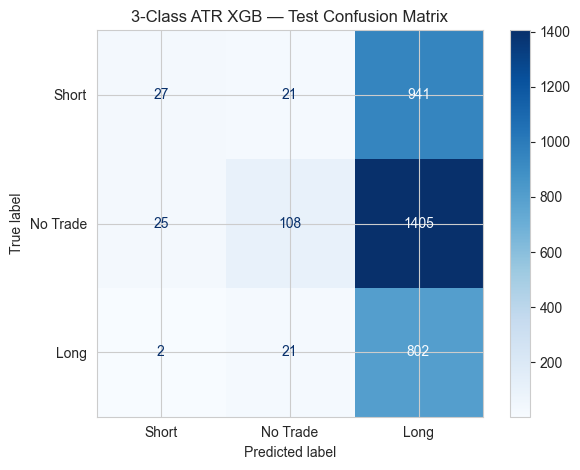

True class distribution:
y_3cls
0    0.295048
1    0.458831
2    0.246122
Name: proportion, dtype: float64
Predicted class distribution:
0    0.016110
1    0.044749
2    0.939141
Name: proportion, dtype: float64
Probability summary:


,p_short,p_hold,p_long,trade_confidence
count,3352.000000,3352.000000,3352.000000,3352.000000
mean,0.152728,0.197835,0.649438,0.652302
std,0.069943,0.078060,0.128159,0.120418
min,0.046007,0.074145,0.152128,0.152128
25%,0.108318,0.151213,0.625123,0.625123
50%,0.132552,0.175119,0.686475,0.686475
75%,0.172096,0.214417,0.728093,0.728093
max,0.460957,0.701775,0.843533,0.843533


In [36]:
# ============================================================
# CLASSIFICATION DIAGNOSTICS
# ============================================================

class_labels = [0, 1, 2]
class_names = ["Short", "No Trade", "Long"]

print("Classification report:")
print(
    classification_report(
        y_test,
        y_pred,
        labels=class_labels,
        target_names=class_names,
        zero_division=0,
    )
)

cm = confusion_matrix(y_test, y_pred, labels=class_labels)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(cmap="Blues")
plt.title("3-Class ATR XGB — Test Confusion Matrix")
plt.tight_layout()
plt.show()

print("True class distribution:")
print(y_test.value_counts(normalize=True).sort_index())

print("Predicted class distribution:")
print(pd.Series(y_pred, index=X_test.index).value_counts(normalize=True).sort_index())

print("Probability summary:")
display(proba_df[["p_short", "p_hold", "p_long", "trade_confidence"]].describe())


### Validation Strategy Selection, Then Final Test Evaluation

Strategy/session/hour selection is performed on the validation block only. The final test set is then evaluated once using the selected rules, a fixed validation cutoff, and a no-overlap cooldown equal to the model horizon.


In [37]:
# ============================================================
# VALIDATION STRATEGY SELECTION, THEN FINAL TEST EVALUATION
# ============================================================

COOLDOWN_BARS = horizon
MAX_TRADES_PER_DAY = None

SESSION_CANDIDATES = [None, "Asia", "London", "NY", "NY_late"]
DIRECTION_CANDIDATES = ["both", "long", "short"]
HOUR_FILTER_CANDIDATES = [None, (13, 14)]  # Explicitly test the 13–14 UTC concentration filter.

MIN_VALIDATION_TRADES = 15
MIN_VALIDATION_PF = 1.00
MIN_VALIDATION_AVG_TRADE = 0.0


def run_strategy_grid(
    base_df,
    proba_frame,
    horizon,
    pip_cost,
    sessions,
    directions,
    hour_filters,
    cooldown_bars=None,
    max_trades_per_day=None,
):
    rows = []
    outputs = {}

    for session_filter in sessions:
        for direction in directions:
            for allowed_hours in hour_filters:
                label = strategy_label(session_filter, direction, allowed_hours)

                eval_candidate, trades_candidate, metrics_candidate = evaluate_signal_strategy(
                    base_df,
                    proba_frame,
                    horizon=horizon,
                    pip_cost=pip_cost,
                    session_filter=session_filter,
                    direction=direction,
                    cooldown_bars=cooldown_bars,
                    allowed_hours=allowed_hours,
                    max_trades_per_day=max_trades_per_day,
                )

                row = {
                    "strategy": label,
                    "session": session_filter if session_filter is not None else "ALL",
                    "direction": direction,
                    "allowed_hours": "ALL" if allowed_hours is None else ",".join(map(str, allowed_hours)),
                    "cooldown_bars": cooldown_bars,
                    "trades": metrics_candidate["total_trades"],
                    "long_trades": metrics_candidate["long_trades"],
                    "short_trades": metrics_candidate["short_trades"],
                    "trade_rate": metrics_candidate["trade_rate"],
                    "win_rate": metrics_candidate["win_rate"],
                    "avg_net_per_trade": metrics_candidate["avg_net_per_trade"],
                    "median_net_per_trade": metrics_candidate["median_net_per_trade"],
                    "profit_factor": metrics_candidate["profit_factor"],
                    "total_net": metrics_candidate["total_net"],
                    "max_drawdown": metrics_candidate["max_drawdown"],
                    "sharpe_like": metrics_candidate["sharpe_like"],
                }
                row["score"] = score_strategy_row(row)
                rows.append(row)

                outputs[label] = {
                    "eval_df": eval_candidate,
                    "trades": trades_candidate,
                    "metrics": metrics_candidate,
                    "session_filter": session_filter,
                    "direction": direction,
                    "allowed_hours": allowed_hours,
                }

    return pd.DataFrame(rows), outputs


validation_strategy_results, validation_strategy_outputs = run_strategy_grid(
    df_val,
    val_proba_df,
    horizon=horizon,
    pip_cost=pip_cost,
    sessions=SESSION_CANDIDATES,
    directions=DIRECTION_CANDIDATES,
    hour_filters=HOUR_FILTER_CANDIDATES,
    cooldown_bars=COOLDOWN_BARS,
    max_trades_per_day=MAX_TRADES_PER_DAY,
)

rank_df = validation_strategy_results.copy()
rank_df["pf_rank_value"] = rank_df["profit_factor"].replace([np.inf, -np.inf], np.nan).fillna(0).clip(upper=5)
rank_df["avg_rank_value"] = rank_df["avg_net_per_trade"].fillna(-999)

eligible = rank_df[
    (rank_df["trades"] >= MIN_VALIDATION_TRADES)
    & (rank_df["pf_rank_value"] >= MIN_VALIDATION_PF)
    & (rank_df["avg_rank_value"] > MIN_VALIDATION_AVG_TRADE)
].copy()

if eligible.empty:
    print("No validation strategy passed the minimum quality filters.")
    print("Selecting the highest-scoring validation strategy as a diagnostic fallback, not as a tradable result.")
    selected_row = rank_df.sort_values(["score", "trades"], ascending=False).iloc[0]
    selected_strategy_passed_quality_gate = False
else:
    selected_row = eligible.sort_values(["score", "trades"], ascending=False).iloc[0]
    selected_strategy_passed_quality_gate = True

selected_strategy = selected_row["strategy"]
selected_session_filter = validation_strategy_outputs[selected_strategy]["session_filter"]
selected_direction = validation_strategy_outputs[selected_strategy]["direction"]
selected_allowed_hours = validation_strategy_outputs[selected_strategy]["allowed_hours"]

# Final test evaluation — selected on validation, evaluated on untouched test.
eval_df, trades, metrics = evaluate_signal_strategy(
    df_test,
    proba_df,
    horizon=horizon,
    pip_cost=pip_cost,
    session_filter=selected_session_filter,
    direction=selected_direction,
    cooldown_bars=COOLDOWN_BARS,
    allowed_hours=selected_allowed_hours,
    max_trades_per_day=MAX_TRADES_PER_DAY,
)

# Diagnostic only: evaluate the full grid on test, but do not use it for selection.
test_strategy_results, test_strategy_outputs = run_strategy_grid(
    df_test,
    proba_df,
    horizon=horizon,
    pip_cost=pip_cost,
    sessions=SESSION_CANDIDATES,
    directions=DIRECTION_CANDIDATES,
    hour_filters=HOUR_FILTER_CANDIDATES,
    cooldown_bars=COOLDOWN_BARS,
    max_trades_per_day=MAX_TRADES_PER_DAY,
)

# Backwards-compatible aliases used by later cells.
strategy_results = validation_strategy_results.copy()
strategy_outputs = validation_strategy_outputs.copy()

# Backwards-compatible metric variables for the MLflow cell.
total_trades = metrics["total_trades"]
trade_rate = metrics["trade_rate"]
win_rate = metrics["win_rate"]
avg_net_per_trade = metrics["avg_net_per_trade"]
avg_net_per_step = metrics["avg_net_per_step"]
profit_factor = metrics["profit_factor"]
sharpe_like = metrics["sharpe_like"]
max_dd = metrics["max_drawdown"]
total_net = metrics["total_net"]

print("Validation strategy comparison — used for selection:")
display(validation_strategy_results.sort_values(["score", "trades"], ascending=False))

print("\nDiagnostic test strategy comparison — not used for selection:")
display(test_strategy_results.sort_values(["score", "trades"], ascending=False))

print(f"\nSelected final strategy from validation: {selected_strategy}")
print(f"Passed validation quality gate: {selected_strategy_passed_quality_gate}")
print(f"Selected session filter: {selected_session_filter if selected_session_filter is not None else 'ALL'}")
print(f"Selected direction: {selected_direction}")
print(f"Selected hour filter: {selected_allowed_hours if selected_allowed_hours is not None else 'ALL'}")
print(f"Cooldown bars: {COOLDOWN_BARS}")
print("\nFinal untouched test metrics:")
print_strategy_metrics(metrics)


Validation strategy comparison — used for selection:


,strategy,session,direction,allowed_hours,cooldown_bars,trades,long_trades,short_trades,trade_rate,win_rate,avg_net_per_trade,median_net_per_trade,profit_factor,total_net,max_drawdown,sharpe_like,score
5,ALL_short_h13_14,ALL,short,"13,14",6,1,0,1,0.000298,1.000000,0.000378,0.000378,inf,0.000378,0.000000,4.652429,5.960710
22,NY_short_allhours,NY,short,ALL,6,1,0,1,0.000298,1.000000,0.000378,0.000378,inf,0.000378,0.000000,4.652429,5.960710
23,NY_short_h13_14,NY,short,"13,14",6,1,0,1,0.000298,1.000000,0.000378,0.000378,inf,0.000378,0.000000,4.652429,5.960710
8,Asia_long_allhours,Asia,long,ALL,6,34,34,0,0.010140,0.705882,0.000077,0.000087,2.004512,0.002612,-0.000923,6.765346,1.892923
6,Asia_both_allhours,Asia,both,ALL,6,38,34,4,0.011333,0.710526,0.000069,0.000087,1.896673,0.002617,-0.000923,6.630864,1.781841
26,NY_late_long_allhours,NY_late,long,ALL,6,37,37,0,0.011035,0.486486,0.000036,-0.000086,1.208171,0.001328,-0.003082,1.549505,1.117340
24,NY_late_both_allhours,NY_late,both,ALL,6,38,37,1,0.011333,0.473684,0.000033,-0.000086,1.192115,0.001242,-0.003167,1.448915,1.075447
10,Asia_short_allhours,Asia,short,ALL,6,4,0,4,0.001193,0.750000,0.000001,0.000088,1.015924,0.000005,-0.000318,0.061887,0.732147
2,ALL_long_allhours,ALL,long,ALL,6,158,158,0,0.047122,0.500000,-0.000030,-0.000029,0.868410,-0.004749,-0.013289,-2.746924,0.386229
0,ALL_both_allhours,ALL,both,ALL,6,169,158,11,0.050403,0.502959,-0.000031,0.000028,0.860751,-0.005231,-0.013765,-3.002629,0.377731



Diagnostic test strategy comparison — not used for selection:


,strategy,session,direction,allowed_hours,cooldown_bars,trades,long_trades,short_trades,trade_rate,win_rate,avg_net_per_trade,median_net_per_trade,profit_factor,total_net,max_drawdown,sharpe_like,score
1,ALL_both_h13_14,ALL,both,"13,14",6,40,40,0,0.011933,0.600000,0.000112,0.000028,1.508546,0.004485,-0.002489,4.693419,2.034170
3,ALL_long_h13_14,ALL,long,"13,14",6,40,40,0,0.011933,0.600000,0.000112,0.000028,1.508546,0.004485,-0.002489,4.693419,2.034170
19,NY_both_h13_14,NY,both,"13,14",6,40,40,0,0.011933,0.600000,0.000112,0.000028,1.508546,0.004485,-0.002489,4.693419,2.034170
21,NY_long_h13_14,NY,long,"13,14",6,40,40,0,0.011933,0.600000,0.000112,0.000028,1.508546,0.004485,-0.002489,4.693419,2.034170
18,NY_both_allhours,NY,both,ALL,6,100,100,0,0.029833,0.510000,-0.000029,0.000026,0.876284,-0.002946,-0.007666,-2.375642,0.389241
20,NY_long_allhours,NY,long,ALL,6,100,100,0,0.029833,0.510000,-0.000029,0.000026,0.876284,-0.002946,-0.007666,-2.375642,0.389241
6,Asia_both_allhours,Asia,both,ALL,6,175,175,0,0.052208,0.405714,-0.000096,-0.000088,0.575202,-0.016820,-0.019710,-13.078531,-0.420257
8,Asia_long_allhours,Asia,long,ALL,6,175,175,0,0.052208,0.405714,-0.000096,-0.000088,0.575202,-0.016820,-0.019710,-13.078531,-0.420257
0,ALL_both_allhours,ALL,both,ALL,6,493,493,0,0.147076,0.417850,-0.000098,-0.000088,0.559519,-0.048432,-0.049441,-21.759311,-0.445486
2,ALL_long_allhours,ALL,long,ALL,6,493,493,0,0.147076,0.417850,-0.000098,-0.000088,0.559519,-0.048432,-0.049441,-21.759311,-0.445486



Selected final strategy from validation: Asia_long_allhours
Passed validation quality gate: True
Selected session filter: Asia
Selected direction: long
Selected hour filter: ALL
Cooldown bars: 6

Final untouched test metrics:
Total trades: 175
Trade rate: 5.22%
Win rate: 40.57%
Avg net return per trade: -0.000096
Median net return per trade: -0.000088
Avg net return per step: -0.000005
Profit factor: 0.58
Sharpe-like: -13.08
Max drawdown: -1.97%
Long trades: 175
Short trades: 0
Long avg net: -0.000096
Short avg net: n/a


### Equity Curve

This chart is the held-out test equity curve for the strategy selected on validation. It uses the validation-selected confidence cutoff and the no-overlap cooldown rule.


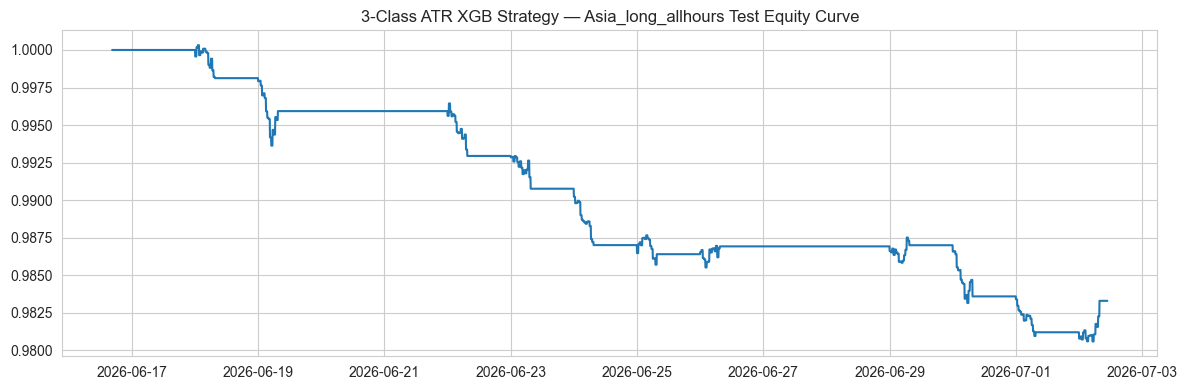

Saved equity curve to images/Asia_long_allhours_equity_curve.png


In [38]:
# ============================================================
# TEST EQUITY CURVE FOR SELECTED STRATEGY
# ============================================================

os.makedirs("images", exist_ok=True)
equity_path = f"images/{selected_strategy}_equity_curve.png"

plt.figure(figsize=(12, 4))
plt.plot(eval_df.index, eval_df["equity"])
plt.title(f"3-Class ATR XGB Strategy — {selected_strategy} Test Equity Curve")
plt.grid(True)
plt.tight_layout()
plt.savefig(equity_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved equity curve to {equity_path}")

### Trade Diagnostics and Monthly Stability

These diagnostics inspect the final validation-selected strategy on the held-out test set, then compare the raw long/short candidates before final session/hour/direction filters.


In [39]:
# ============================================================
# TRADE INSPECTION, GROUP SUMMARIES, MONTHLY STABILITY
# ============================================================

ret_col = f"ret_fwd_{horizon}"

display_cols = [
    "session", "p_short", "p_hold", "p_long", "trade_confidence",
    "signal", ret_col, "gross_ret", "trade_cost", "net_ret",
    "trend_adx", "volatility_atr", "atr_pct",
]
display_cols = [c for c in display_cols if c in eval_df.columns]

if trades.empty:
    print(f"No trades were generated for the selected strategy: {selected_strategy}.")
    monthly_stability = pd.DataFrame(columns=["trades", "total_net", "avg_trade", "win_rate", "profit_factor"])
else:
    print("First 30 final trades:")
    display(trades[display_cols].head(30))

    print("Trades by session:")
    display(trades.groupby("session").apply(aggregate_trade_stats))

    print("Trades by signal:")
    display(trades.groupby("signal").apply(aggregate_trade_stats))

    if "hour" in trades.columns:
        print("Trades by hour:")
        display(trades.groupby("hour").apply(aggregate_trade_stats))
    elif isinstance(trades.index, pd.DatetimeIndex):
        hourly_trades = trades.assign(hour=trades.index.hour)
        print("Trades by hour:")
        display(hourly_trades.groupby("hour").apply(aggregate_trade_stats))

    if isinstance(trades.index, pd.DatetimeIndex):
        monthly_trades = trades.assign(month=trades.index.to_period("M"))
    else:
        monthly_trades = trades.assign(month=pd.to_datetime(trades.index).to_period("M"))

    monthly_stability = monthly_trades.groupby("month").apply(aggregate_trade_stats)
    print("Monthly stability:")
    display(monthly_stability)

# Raw direction diagnostics before applying selected strategy filters.
raw_direction_eval = df_test.copy()
if ret_col not in raw_direction_eval.columns:
    raw_direction_eval[ret_col] = raw_direction_eval["Close"].shift(-horizon) / raw_direction_eval["Close"] - 1

for col in ["p_short", "p_hold", "p_long", "trade_confidence", "signal_raw"]:
    raw_direction_eval[col] = proba_df[col].to_numpy()

raw_direction_eval["signal"] = raw_direction_eval["signal_raw"].astype(int)
raw_direction_eval["gross_ret"] = raw_direction_eval["signal"] * raw_direction_eval[ret_col]
raw_direction_eval["trade_cost"] = np.where(raw_direction_eval["signal"] != 0, pip_cost / raw_direction_eval["Close"], 0.0)
raw_direction_eval["net_ret"] = raw_direction_eval["gross_ret"] - raw_direction_eval["trade_cost"]
raw_direction_trades = raw_direction_eval[raw_direction_eval["signal"] != 0].copy()

print("Raw long/short diagnostics before selected strategy filter:")
if raw_direction_trades.empty:
    print("No raw confidence-ranked directional trades were generated.")
else:
    display(raw_direction_trades.groupby(["session", "signal"]).apply(aggregate_trade_stats))

First 30 final trades:


,session,p_short,p_hold,p_long,trade_confidence,signal,ret_fwd_6,gross_ret,trade_cost,net_ret,trend_adx,volatility_atr,atr_pct
Datetime,,,,,,,,,,,,,
2026-06-18 00:05:00+00:00,Asia,0.182906,0.193157,0.623936,0.623936,1,-0.000345,-0.000345,0.000087,-0.000432,17.524702,0.000257,0.000223
2026-06-18 00:35:00+00:00,Asia,0.151217,0.147652,0.701131,0.701131,1,0.000691,0.000691,0.000087,0.000604,19.453817,0.000206,0.000179
2026-06-18 01:05:00+00:00,Asia,0.149872,0.169162,0.680966,0.680966,1,0.000231,0.000231,0.000087,0.000144,23.364096,0.000226,0.000196
2026-06-18 01:35:00+00:00,Asia,0.223605,0.173172,0.603223,0.603223,1,-0.000576,-0.000576,0.000087,-0.000663,31.867140,0.000194,0.000169
2026-06-18 02:05:00+00:00,Asia,0.159040,0.180569,0.660390,0.660390,1,0.000346,0.000346,0.000087,0.000259,26.251231,0.000201,0.000175
2026-06-18 02:35:00+00:00,Asia,0.157813,0.170125,0.672062,0.672062,1,0.000000,0.000000,0.000087,-0.000087,19.676374,0.000191,0.000166
2026-06-18 03:05:00+00:00,Asia,0.118387,0.173944,0.707669,0.707669,1,0.000346,0.000346,0.000087,0.000259,22.322714,0.000172,0.000150
2026-06-18 04:00:00+00:00,Asia,0.175408,0.204378,0.620215,0.620215,1,-0.000115,-0.000115,0.000087,-0.000202,28.940240,0.000130,0.000113
2026-06-18 04:35:00+00:00,Asia,0.205307,0.233361,0.561332,0.561332,1,0.000000,0.000000,0.000087,-0.000087,20.928303,0.000132,0.000115


Trades by session:


,trades,total_net,avg_trade,median_trade,win_rate,profit_factor
session,,,,,,
Asia,175.0,-0.01682,-0.000096,-0.000088,0.405714,0.575202


Trades by signal:


...

,trades,total_net,avg_trade,median_trade,win_rate,profit_factor
hour,,,,,,
0,22.0,-0.001919,-0.000087,-0.000145,0.409091,0.568532
1,22.0,-0.004219,-0.000192,-0.000202,0.318182,0.269165
2,22.0,-0.001580,-0.000072,-0.000087,0.454545,0.555706
3,21.0,-0.003216,-0.000153,-0.000202,0.333333,0.397740
4,22.0,-0.003756,-0.000171,-0.000088,0.272727,0.162299
5,22.0,-0.001363,-0.000062,-0.000088,0.500000,0.689763
6,22.0,0.001852,0.000084,0.000141,0.590909,1.387540
7,22.0,-0.002619,-0.000119,-0.000202,0.363636,0.616030


Monthly stability:


,trades,total_net,avg_trade,median_trade,win_rate,profit_factor
month,,,,,,
2026-06,143.0,-0.016522,-0.000116,-0.000088,0.391608,0.520497
2026-07,32.0,-0.000298,-0.000009,-0.000088,0.468750,0.942049


Raw long/short diagnostics before selected strategy filter:


,,trades,total_net,avg_trade,median_trade,win_rate,profit_factor
session,signal,,,,,,
Asia,1,1023.0,-0.094066,-0.000092,-0.000088,0.434018,0.598114
London,1,635.0,-0.094584,-0.000149,-0.000202,0.398425,0.491836
NY,1,562.0,-0.027644,-0.000049,-0.000087,0.467972,0.796523
NY_late,1,636.0,-0.075089,-0.000118,-0.000088,0.341195,0.339254


### Validation-Based Confidence Threshold Sweep

The sweep recalculates each confidence cutoff on validation probabilities and applies that fixed cutoff to the final test set. This avoids choosing thresholds from the future test distribution.


,quantile,validation_cutoff,trades,trade_rate,win_rate,avg_trade,median_trade,total_net,profit_factor,max_drawdown
0,0.50,0.463519,178,0.053103,0.426966,-0.000099,-0.000088,-0.017645,0.553738,-0.020244
1,0.60,0.491022,176,0.052506,0.414773,-0.000103,-0.000088,-0.018051,0.549698,-0.020470
2,0.70,0.516301,175,0.052208,0.405714,-0.000093,-0.000088,-0.016358,0.579568,-0.019257
3,0.75,0.530831,175,0.052208,0.405714,-0.000093,-0.000088,-0.016358,0.579568,-0.019257
4,0.80,0.548725,175,0.052208,0.405714,-0.000096,-0.000088,-0.016820,0.575202,-0.019710
5,0.85,0.569364,174,0.051909,0.413793,-0.000100,-0.000088,-0.017422,0.569359,-0.020301
6,0.90,0.603874,171,0.051014,0.421053,-0.000091,-0.000088,-0.015550,0.596970,-0.018662
7,0.95,0.651620,165,0.049224,0.478788,-0.000079,-0.000088,-0.012962,0.648394,-0.017373


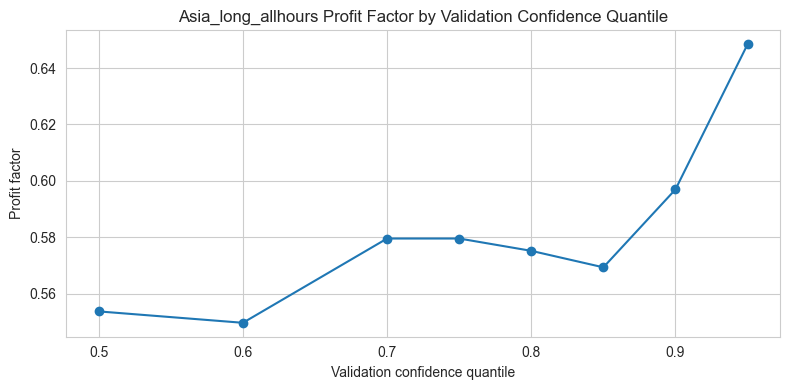

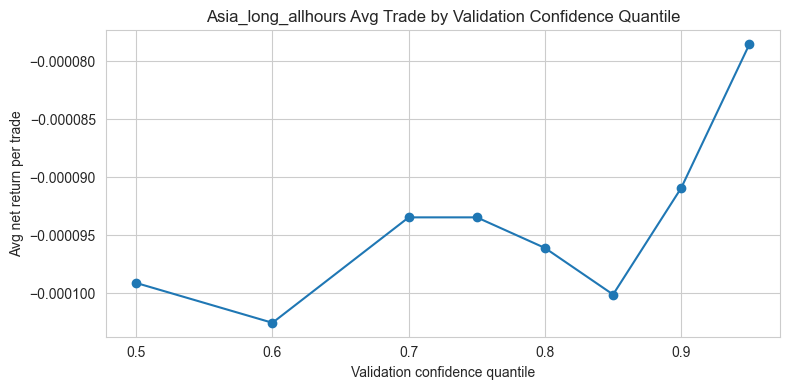

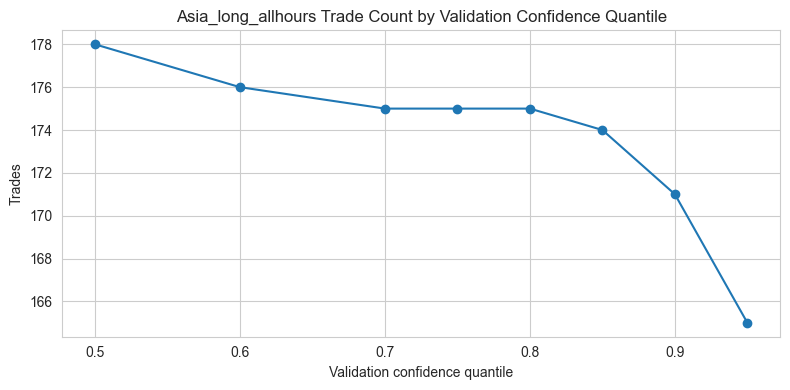

Saved threshold results to images/Asia_long_allhours_validation_threshold_results.csv


In [40]:
# ============================================================
# VALIDATION-BASED CONFIDENCE QUANTILE SWEEP FOR SELECTED STRATEGY
# ============================================================

def run_validation_based_threshold_sweep(
    validation_proba,
    validation_index,
    test_proba_raw,
    test_index,
    base_df,
    quantiles,
    horizon,
    pip_cost,
    validation_classes=None,
    test_classes=None,
    session_filter=None,
    direction="both",
    cooldown_bars=None,
    allowed_hours=None,
    max_trades_per_day=None,
):
    rows = []

    for q in quantiles:
        _, cutoff = build_confidence_signals(
            validation_proba,
            validation_index,
            q,
            classes=validation_classes,
        )

        sweep_proba = build_signals_with_fixed_cutoff(
            test_proba_raw,
            test_index,
            cutoff=cutoff,
            classes=test_classes,
        )

        sweep_eval, sweep_trades, sweep_metrics = evaluate_signal_strategy(
            base_df,
            sweep_proba,
            horizon=horizon,
            pip_cost=pip_cost,
            session_filter=session_filter,
            direction=direction,
            cooldown_bars=cooldown_bars,
            allowed_hours=allowed_hours,
            max_trades_per_day=max_trades_per_day,
        )

        rows.append({
            "quantile": q,
            "validation_cutoff": cutoff,
            "trades": sweep_metrics["total_trades"],
            "trade_rate": sweep_metrics["trade_rate"],
            "win_rate": sweep_metrics["win_rate"],
            "avg_trade": sweep_metrics["avg_net_per_trade"],
            "median_trade": sweep_metrics["median_net_per_trade"],
            "total_net": sweep_metrics["total_net"],
            "profit_factor": sweep_metrics["profit_factor"],
            "max_drawdown": sweep_metrics["max_drawdown"],
        })

    return pd.DataFrame(rows)


threshold_quantiles = [0.50, 0.60, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
threshold_results = run_validation_based_threshold_sweep(
    val_proba_raw,
    X_val.index,
    test_proba_raw,
    X_test.index,
    df_test,
    threshold_quantiles,
    horizon=horizon,
    pip_cost=pip_cost,
    validation_classes=val_classes,
    test_classes=test_classes,
    session_filter=selected_session_filter,
    direction=selected_direction,
    cooldown_bars=COOLDOWN_BARS,
    allowed_hours=selected_allowed_hours,
    max_trades_per_day=MAX_TRADES_PER_DAY,
)

display(threshold_results)

os.makedirs("images", exist_ok=True)
threshold_results_path = f"images/{selected_strategy}_validation_threshold_results.csv"
threshold_results.to_csv(threshold_results_path, index=False)

plt.figure(figsize=(8, 4))
plt.plot(threshold_results["quantile"], threshold_results["profit_factor"], marker="o")
plt.title(f"{selected_strategy} Profit Factor by Validation Confidence Quantile")
plt.xlabel("Validation confidence quantile")
plt.ylabel("Profit factor")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(threshold_results["quantile"], threshold_results["avg_trade"], marker="o")
plt.title(f"{selected_strategy} Avg Trade by Validation Confidence Quantile")
plt.xlabel("Validation confidence quantile")
plt.ylabel("Avg net return per trade")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(threshold_results["quantile"], threshold_results["trades"], marker="o")
plt.title(f"{selected_strategy} Trade Count by Validation Confidence Quantile")
plt.xlabel("Validation confidence quantile")
plt.ylabel("Trades")
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Saved threshold results to {threshold_results_path}")


### Cost Stress Test

The strategy should not be considered robust unless it survives meaningfully higher transaction costs, especially 1.5x to 2x the current estimate.


In [ ]:
# ============================================================
# COST STRESS TEST FOR VALIDATION-SELECTED STRATEGY
# ============================================================

def run_cost_stress(
    base_df,
    proba_frame,
    multipliers,
    horizon,
    pip_cost,
    session_filter=None,
    direction="both",
    cooldown_bars=None,
    allowed_hours=None,
    max_trades_per_day=None,
):
    rows = []

    for multiplier in multipliers:
        stress_eval, stress_trades, stress_metrics = evaluate_signal_strategy(
            base_df,
            proba_frame,
            horizon=horizon,
            pip_cost=pip_cost,
            cost_multiplier=multiplier,
            session_filter=session_filter,
            direction=direction,
            cooldown_bars=cooldown_bars,
            allowed_hours=allowed_hours,
            max_trades_per_day=max_trades_per_day,
        )

        rows.append({
            "cost_multiplier": multiplier,
            "effective_pip_cost": pip_cost * multiplier,
            "trades": stress_metrics["total_trades"],
            "win_rate": stress_metrics["win_rate"],
            "avg_trade": stress_metrics["avg_net_per_trade"],
            "median_trade": stress_metrics["median_net_per_trade"],
            "total_net": stress_metrics["total_net"],
            "profit_factor": stress_metrics["profit_factor"],
            "max_drawdown": stress_metrics["max_drawdown"],
        })

    return pd.DataFrame(rows)


cost_multipliers = [0.5, 1.0, 1.5, 2.0, 3.0]
cost_stress_results = run_cost_stress(
    df_test,
    proba_df,
    cost_multipliers,
    horizon=horizon,
    pip_cost=pip_cost,
    session_filter=selected_session_filter,
    direction=selected_direction,
    cooldown_bars=COOLDOWN_BARS,
    allowed_hours=selected_allowed_hours,
    max_trades_per_day=MAX_TRADES_PER_DAY,
)

display(cost_stress_results)

os.makedirs("data", exist_ok=True)
cost_stress_results_path = f"data/{selected_strategy}_cost_stress_results.csv"
cost_stress_results.to_csv(cost_stress_results_path, index=False)
print(f"Saved cost stress results to {cost_stress_results_path}")


,cost_multiplier,effective_pip_cost,trades,win_rate,avg_trade,median_trade,total_net,profit_factor,max_drawdown
0,0.5,0.00005,175,0.405714,-0.000052,-0.000044,-0.009154,0.738760,-0.012752
1,1.0,0.00010,175,0.405714,-0.000096,-0.000088,-0.016820,0.575202,-0.019710
2,1.5,0.00015,175,0.302857,-0.000140,-0.000132,-0.024485,0.449319,-0.026857
3,2.0,0.00020,175,0.302857,-0.000184,-0.000176,-0.032151,0.354486,-0.033952
4,3.0,0.00030,175,0.228571,-0.000271,-0.000264,-0.047482,0.220940,-0.048183


Saved cost stress results to images/Asia_long_allhours_cost_stress_results.csv


### Walk-Forward Validation

This expanding-window validation now chooses each fold's confidence cutoff using only the fold's internal validation tail, then applies that fixed cutoff to the fold's out-of-sample test window. The selected session/direction/hour/cooldown rules come from the earlier validation selection step.


In [ ]:
# ============================================================
# EXPANDING-WINDOW WALK-FORWARD VALIDATION WITH INTERNAL CUTOFF VALIDATION
# ============================================================

def make_final_xgb_from_params(params):
    return XGBClassifier(
        **params,
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=42,
        n_jobs=-1,
    )


def run_walk_forward_validation(
    data,
    numeric_features,
    categorical_features,
    preprocess,
    best_params,
    trade_quantile,
    horizon,
    pip_cost,
    session_filter=None,
    direction="both",
    cooldown_bars=None,
    allowed_hours=None,
    max_trades_per_day=None,
    min_train_frac=0.50,
    test_window_frac=0.10,
    step_frac=0.10,
    internal_validation_frac=0.20,
):
    wf_df = data.copy().sort_index()
    ret_col = f"ret_fwd_{horizon}"

    if ret_col not in wf_df.columns:
        wf_df[ret_col] = wf_df["Close"].shift(-horizon) / wf_df["Close"] - 1

    feature_cols = numeric_features + categorical_features
    wf_df = wf_df.dropna(subset=feature_cols + ["y_3cls", ret_col]).copy()

    n = len(wf_df)
    min_train_size = max(int(n * min_train_frac), 150)
    test_window = max(int(n * test_window_frac), 1)
    step_size = max(int(n * step_frac), 1)

    rows = []
    fold = 0

    for train_end in range(min_train_size, n - test_window + 1, step_size):
        test_start = train_end
        test_end = min(test_start + test_window, n)

        train_df = wf_df.iloc[:train_end].copy()
        test_df_fold = wf_df.iloc[test_start:test_end].copy()

        if test_df_fold.empty:
            continue

        internal_val_size = max(int(len(train_df) * internal_validation_frac), 50)
        if len(train_df) - internal_val_size < 100:
            print(f"Skipping fold ending {train_df.index.max()} because internal train/validation split is too small.")
            continue

        fit_df = train_df.iloc[:-internal_val_size].copy()
        cutoff_df = train_df.iloc[-internal_val_size:].copy()

        if set(fit_df["y_3cls"].dropna().astype(int).unique()) != {0, 1, 2}:
            print(f"Skipping fold ending {fit_df.index.max()} because fit data lacks all 3 classes.")
            continue

        if set(train_df["y_3cls"].dropna().astype(int).unique()) != {0, 1, 2}:
            print(f"Skipping fold ending {train_df.index.max()} because full training data lacks all 3 classes.")
            continue

        X_fit = fit_df[feature_cols]
        y_fit = fit_df["y_3cls"].astype(int)
        X_cutoff = cutoff_df[feature_cols]

        cutoff_model = Pipeline([
            ("preprocess", clone(preprocess)),
            ("model", make_final_xgb_from_params(best_params)),
        ])

        cutoff_weight = compute_sample_weight(class_weight="balanced", y=y_fit)
        cutoff_model.fit(X_fit, y_fit, model__sample_weight=cutoff_weight)

        cutoff_proba_raw = cutoff_model.predict_proba(X_cutoff)
        cutoff_classes = cutoff_model.named_steps["model"].classes_
        _, fold_cutoff = build_confidence_signals(
            cutoff_proba_raw,
            X_cutoff.index,
            trade_quantile,
            classes=cutoff_classes,
        )

        # Refit on the full expanding training block, then apply the fold cutoff to the OOS window.
        X_tr = train_df[feature_cols]
        y_tr = train_df["y_3cls"].astype(int)
        X_te = test_df_fold[feature_cols]

        fold_model = Pipeline([
            ("preprocess", clone(preprocess)),
            ("model", make_final_xgb_from_params(best_params)),
        ])

        sample_weight = compute_sample_weight(class_weight="balanced", y=y_tr)
        fold_model.fit(X_tr, y_tr, model__sample_weight=sample_weight)

        fold_proba_raw = fold_model.predict_proba(X_te)
        fold_classes = fold_model.named_steps["model"].classes_
        fold_proba = build_signals_with_fixed_cutoff(
            fold_proba_raw,
            X_te.index,
            cutoff=fold_cutoff,
            classes=fold_classes,
        )

        _, fold_trades, fold_metrics = evaluate_signal_strategy(
            test_df_fold,
            fold_proba,
            horizon=horizon,
            pip_cost=pip_cost,
            session_filter=session_filter,
            direction=direction,
            cooldown_bars=cooldown_bars,
            allowed_hours=allowed_hours,
            max_trades_per_day=max_trades_per_day,
        )

        fold += 1
        rows.append({
            "fold": fold,
            "fit_start": fit_df.index.min(),
            "fit_end": fit_df.index.max(),
            "cutoff_start": cutoff_df.index.min(),
            "cutoff_end": cutoff_df.index.max(),
            "test_start": test_df_fold.index.min(),
            "test_end": test_df_fold.index.max(),
            "confidence_cutoff": fold_cutoff,
            "trades": fold_metrics["total_trades"],
            "long_trades": fold_metrics["long_trades"],
            "short_trades": fold_metrics["short_trades"],
            "win_rate": fold_metrics["win_rate"],
            "avg_trade": fold_metrics["avg_net_per_trade"],
            "median_trade": fold_metrics["median_net_per_trade"],
            "total_net": fold_metrics["total_net"],
            "profit_factor": fold_metrics["profit_factor"],
            "max_drawdown": fold_metrics["max_drawdown"],
            "sharpe_like": fold_metrics["sharpe_like"],
        })

    return pd.DataFrame(rows)


walkforward_results = run_walk_forward_validation(
    model_df,
    numeric_features,
    categorical_features,
    preprocess,
    best_params,
    trade_quantile,
    horizon,
    pip_cost,
    session_filter=selected_session_filter,
    direction=selected_direction,
    cooldown_bars=COOLDOWN_BARS,
    allowed_hours=selected_allowed_hours,
    max_trades_per_day=MAX_TRADES_PER_DAY,
)

display(walkforward_results)

if walkforward_results.empty:
    walkforward_summary = pd.Series(dtype=float)
    walkforward_positive_fold_rate = np.nan
    print("No walk-forward folds were produced. Check data length and split settings.")
else:
    walkforward_summary = walkforward_results[[
        "trades", "win_rate", "avg_trade", "median_trade", "total_net", "profit_factor", "max_drawdown", "sharpe_like"
    ]].replace([np.inf, -np.inf], np.nan).mean(numeric_only=True)

    walkforward_positive_fold_rate = (walkforward_results["total_net"] > 0).mean()

    print("Walk-forward summary averages:")
    display(walkforward_summary)
    print(f"Positive fold rate: {walkforward_positive_fold_rate:.2%}")

os.makedirs("data", exist_ok=True)
walkforward_results_path = f"data/{selected_strategy}_walkforward_results.csv"
walkforward_results.to_csv(walkforward_results_path, index=False)
print(f"Saved walk-forward results to {walkforward_results_path}")


,fold,fit_start,fit_end,cutoff_start,cutoff_end,test_start,test_end,confidence_cutoff,trades,long_trades,short_trades,win_rate,avg_trade,median_trade,total_net,profit_factor,max_drawdown,sharpe_like
0,1,2026-04-10 03:05:00+00:00,2026-05-14 02:05:00+00:00,2026-05-14 02:10:00+00:00,2026-05-21 23:15:00+00:00,2026-05-21 23:20:00+00:00,2026-05-29 20:25:00+00:00,0.665288,1,1,0,0.000000,-0.000202,-0.000202,-0.000202,0.000000,-0.000202,-6.580509
1,2,2026-04-10 03:05:00+00:00,2026-05-20 19:20:00+00:00,2026-05-20 19:25:00+00:00,2026-05-29 20:25:00+00:00,2026-05-29 20:30:00+00:00,2026-06-08 19:05:00+00:00,0.462417,21,21,0,0.476190,-0.000114,-0.000086,-0.002388,0.498289,-0.002387,-7.155582
2,3,2026-04-10 03:05:00+00:00,2026-05-27 12:35:00+00:00,2026-05-27 12:40:00+00:00,2026-06-08 19:05:00+00:00,2026-06-08 19:10:00+00:00,2026-06-16 16:15:00+00:00,0.507356,9,9,0,0.555556,0.000119,0.000030,0.001074,2.326785,-0.000693,6.010180
3,4,2026-04-10 03:05:00+00:00,2026-06-03 05:45:00+00:00,2026-06-03 05:50:00+00:00,2026-06-16 16:15:00+00:00,2026-06-16 16:20:00+00:00,2026-06-24 13:25:00+00:00,0.543650,79,79,0,0.329114,-0.000158,-0.000202,-0.012487,0.417843,-0.012730,-18.863015
4,5,2026-04-10 03:05:00+00:00,2026-06-09 23:00:00+00:00,2026-06-09 23:05:00+00:00,2026-06-24 13:25:00+00:00,2026-06-24 13:30:00+00:00,2026-07-02 10:35:00+00:00,0.635978,0,0,0,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN


Walk-forward summary averages:


trades           22.000000
win_rate          0.340215
avg_trade        -0.000089
median_trade     -0.000115
total_net        -0.002801
profit_factor     0.810729
max_drawdown     -0.003202
sharpe_like      -6.647232
dtype: float64

Positive fold rate: 20.00%
Saved walk-forward results to images/Asia_long_allhours_walkforward_results.csv


### Backtrader Execution Backtest

This section runs only after ML signal validation, threshold selection, cost stress, and walk-forward validation. It uses the final `eval_df` signal column so the Backtrader test follows the same validation-selected strategy, fixed cutoff, hour filter, and cooldown logic.


In [ ]:
# ============================================================
# BACKTRADER BACKTEST FOR VALIDATION-SELECTED ML SIGNALS
# ============================================================

backtrader_results_path = None
backtrader_metrics = {}

if bt is None:
    print("Backtrader is not installed/available, so the execution-style backtest was skipped.")
    print("Install it in your environment with: pip install backtrader")
else:
    class MLSignalData(bt.feeds.PandasData):
        lines = ("signal",)

        params = (
            ("datetime", None),
            ("open", "Open"),
            ("high", "High"),
            ("low", "Low"),
            ("close", "Close"),
            ("volume", None),
            ("openinterest", None),
            ("signal", "signal"),
        )


    class MLSignalStrategy(bt.Strategy):
        params = dict(
            stake=1000,          # 0.01 lot = 1,000 units
            hold_bars=6,         # same as model horizon
            allow_short=True,
            max_trades_per_day=None,
        )

        def __init__(self):
            self.order = None
            self.bars_in_trade = 0
            self.current_day = None
            self.trades_today = 0

        def notify_order(self, order):
            if order.status in [order.Completed, order.Canceled, order.Margin, order.Rejected]:
                self.order = None

        def next(self):
            if self.order:
                return

            dt = self.data.datetime.datetime(0)
            day = dt.date()

            if self.current_day != day:
                self.current_day = day
                self.trades_today = 0

            signal = int(self.data.signal[0])

            if self.position:
                self.bars_in_trade += 1
                if self.bars_in_trade >= self.p.hold_bars:
                    self.order = self.close()
                    self.bars_in_trade = 0
                return

            if self.p.max_trades_per_day is not None and self.trades_today >= self.p.max_trades_per_day:
                return

            if signal == 1:
                self.order = self.buy(size=self.p.stake)
                self.bars_in_trade = 0
                self.trades_today += 1

            elif signal == -1 and self.p.allow_short:
                self.order = self.sell(size=self.p.stake)
                self.bars_in_trade = 0
                self.trades_today += 1


    bt_df = eval_df[["Open", "High", "Low", "Close", "signal"]].copy().dropna()

    if isinstance(bt_df.index, pd.DatetimeIndex) and bt_df.index.tz is not None:
        bt_df.index = bt_df.index.tz_convert(None)

    cerebro = bt.Cerebro(stdstats=True)
    data_feed = MLSignalData(dataname=bt_df)
    cerebro.adddata(data_feed)

    cerebro.addstrategy(
        MLSignalStrategy,
        stake=1000,
        hold_bars=horizon,
        allow_short=True,
        max_trades_per_day=MAX_TRADES_PER_DAY,
    )

    # Starting capital is intentionally close to your small-account research assumption.
    # FX margin/leverage treatment is still approximate in Backtrader unless connected to broker-specific rules.
    cerebro.broker.setcash(200.0)

    # Approximate one-pip slippage/spread as a percentage of price.
    # Tune this after you know your broker's real spread and commission model.
    cerebro.broker.set_slippage_perc(perc=0.0001)
    cerebro.broker.setcommission(commission=0.0, leverage=50)

    cerebro.addanalyzer(bt.analyzers.TradeAnalyzer, _name="trades")
    cerebro.addanalyzer(bt.analyzers.DrawDown, _name="drawdown")
    cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name="sharpe")
    cerebro.addanalyzer(bt.analyzers.SQN, _name="sqn")
    cerebro.addanalyzer(bt.analyzers.Returns, _name="returns")

    start_value = cerebro.broker.getvalue()
    results = cerebro.run()
    strat = results[0]
    end_value = cerebro.broker.getvalue()

    trade_analysis = strat.analyzers.trades.get_analysis()
    drawdown_analysis = strat.analyzers.drawdown.get_analysis()
    sharpe_analysis = strat.analyzers.sharpe.get_analysis()
    sqn_analysis = strat.analyzers.sqn.get_analysis()
    returns_analysis = strat.analyzers.returns.get_analysis()

    backtrader_metrics = {
        "start_value": start_value,
        "end_value": end_value,
        "net_pnl": end_value - start_value,
        "trade_analysis": dict(trade_analysis),
        "drawdown": dict(drawdown_analysis),
        "sharpe": dict(sharpe_analysis),
        "sqn": dict(sqn_analysis),
        "returns": dict(returns_analysis),
    }

    print(f"Start value: {start_value:.2f}")
    print(f"End value:   {end_value:.2f}")
    print(f"Net PnL:     {end_value - start_value:.2f}")
    print("Trade analysis:")
    print(trade_analysis)
    print("Drawdown:")
    print(drawdown_analysis)
    print("Sharpe:")
    print(sharpe_analysis)
    print("SQN:")
    print(sqn_analysis)
    print("Returns:")
    print(returns_analysis)

    os.makedirs("images", exist_ok=True)
    backtrader_results_path = f"data/{selected_strategy}_backtrader_summary.txt"
    with open(backtrader_results_path, "w", encoding="utf-8") as f:
        f.write(f"Selected strategy: {selected_strategy}\n")
        f.write(f"Start value: {start_value:.2f}\n")
        f.write(f"End value: {end_value:.2f}\n")
        f.write(f"Net PnL: {end_value - start_value:.2f}\n\n")
        f.write(f"Trade analysis:\n{trade_analysis}\n\n")
        f.write(f"Drawdown:\n{drawdown_analysis}\n\n")
        f.write(f"Sharpe:\n{sharpe_analysis}\n\n")
        f.write(f"SQN:\n{sqn_analysis}\n\n")
        f.write(f"Returns:\n{returns_analysis}\n")

    print(f"Saved Backtrader summary to {backtrader_results_path}")


Start value: 200.00
End value:   189.56
Net PnL:     -10.44
Trade analysis:
AutoOrderedDict({'total': AutoOrderedDict({'total': 90, 'open': 0, 'closed': 90}), 'streak': AutoOrderedDict({'won': AutoOrderedDict({'current': 2, 'longest': 6}), 'lost': AutoOrderedDict({'current': 0, 'longest': 7})}), 'pnl': AutoOrderedDict({'gross': AutoOrderedDict({'total': -10.443107688427267, 'average': -0.11603452987141408}), 'net': AutoOrderedDict({'total': -10.443107688427267, 'average': -0.11603452987141408})}), 'won': AutoOrderedDict({'total': 38, 'pnl': AutoOrderedDict({'total': 10.54134759902925, 'average': 0.27740388418498024, 'max': 1.4451933979988674})}), 'lost': AutoOrderedDict({'total': 52, 'pnl': AutoOrderedDict({'total': -20.984455287456512, 'average': -0.4035472170664714, 'max': -1.4272408843041262})}), 'long': AutoOrderedDict({'total': 90, 'pnl': AutoOrderedDict({'total': -10.443107688427267, 'average': -0.11603452987141408, 'won': AutoOrderedDict({'total': 10.54134759902925, 'average': 0

### MLflow Logging

MLflow logs the full sklearn pipeline, not the raw XGB model alone, so preprocessing and model parameters stay together.


In [ ]:
# ============================================================
# MLFLOW LOGGING FOR SELECTED 3-CLASS WORKFLOW
# ============================================================

def lookup_result(df, key_col, key, metric_col):
    if df.empty or key_col not in df.columns or metric_col not in df.columns:
        return np.nan
    matches = df.loc[df[key_col] == key, metric_col]
    return matches.iloc[0] if len(matches) else np.nan


cost_stress_1x_pf = lookup_result(cost_stress_results, "cost_multiplier", 1.0, "profit_factor")
cost_stress_2x_pf = lookup_result(cost_stress_results, "cost_multiplier", 2.0, "profit_factor")
walkforward_avg_pf = (
    walkforward_results["profit_factor"].replace([np.inf, -np.inf], np.nan).mean()
    if not walkforward_results.empty
    else np.nan
)
walkforward_avg_trades = (
    walkforward_results["trades"].mean()
    if not walkforward_results.empty
    else np.nan
)

if mlflow is None:
    print("MLflow is not installed/available, so experiment logging was skipped.")
else:
    mlflow.set_tracking_uri("file:./mlruns")
    mlflow.set_experiment("EURUSD_XGB_Research")

    with mlflow.start_run(run_name=f"xgb_3class_atr_{selected_strategy}_validation"):
        mlflow.log_param("horizon", horizon)
        mlflow.log_param("pip_cost", pip_cost)
        mlflow.log_param("trade_quantile", trade_quantile)
        mlflow.log_param("strategy_filter", selected_strategy)
        mlflow.log_param("selected_session_filter", selected_session_filter if selected_session_filter is not None else "ALL")
        mlflow.log_param("selected_direction", selected_direction)
        mlflow.log_param("selected_allowed_hours", "ALL" if selected_allowed_hours is None else ",".join(map(str, selected_allowed_hours)))
        mlflow.log_param("cooldown_bars", COOLDOWN_BARS)
        mlflow.log_param("fixed_confidence_cutoff", fixed_confidence_cutoff)
        mlflow.log_param("selected_strategy_passed_quality_gate", selected_strategy_passed_quality_gate)
        mlflow.log_param("model_type", "XGBClassifier_multi_softprob")
        mlflow.log_params({f"xgb_{k}": v for k, v in best_params.items()})

        mlflow.log_metric("total_trades", safe_metric(total_trades))
        mlflow.log_metric("trade_rate", safe_metric(trade_rate))
        mlflow.log_metric("win_rate", safe_metric(win_rate))
        mlflow.log_metric("avg_net_per_trade", safe_metric(avg_net_per_trade))
        mlflow.log_metric("total_net", safe_metric(total_net))
        mlflow.log_metric("profit_factor", safe_metric(profit_factor))
        mlflow.log_metric("sharpe_like", safe_metric(sharpe_like))
        mlflow.log_metric("max_drawdown", safe_metric(max_dd))
        mlflow.log_metric("cost_stress_1x_profit_factor", safe_metric(cost_stress_1x_pf))
        mlflow.log_metric("cost_stress_2x_profit_factor", safe_metric(cost_stress_2x_pf))
        mlflow.log_metric("walkforward_average_profit_factor", safe_metric(walkforward_avg_pf))
        mlflow.log_metric("walkforward_average_trades", safe_metric(walkforward_avg_trades))
        mlflow.log_metric("walkforward_positive_fold_rate", safe_metric(walkforward_positive_fold_rate))
        if backtrader_metrics:
            mlflow.log_metric("backtrader_end_value", safe_metric(backtrader_metrics.get("end_value")))
            mlflow.log_metric("backtrader_net_pnl", safe_metric(backtrader_metrics.get("net_pnl")))

        
        signature = mlflow.models.signature.infer_signature(
            X_test,
            test_proba_raw,
        )

        mlflow.sklearn.log_model(
            final_model,
            artifact_path="model",
            signature=signature,
        )

        for artifact_path in [
            equity_path,
            threshold_results_path,
            cost_stress_results_path,
            walkforward_results_path,
            backtrader_results_path,
        ]:
            if artifact_path is not None and os.path.exists(artifact_path):
                mlflow.log_artifact(artifact_path)

    print("MLflow run logged successfully.")

2026/07/02 14:55:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


MLflow run logged successfully.


### Research Conclusion



## 6) Deployment